In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl

# 全局设置

In [13]:
sns.set_theme(context='paper', style='whitegrid', palette='colorblind')   # 设置主题与调色板
plt.rcParams['font.sans-serif'] = ['STHeiti']   # Mac 用来显示中文字体
# plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号
plt.rcParams['figure.dpi'] = 300    # 设置图形分辨率
plt.rcParams['savefig.dpi'] = 300    # 设置保存图形的分辨率

```bash
style: 控制图形的背景和网格线
常用的有 'darkgrid' (默认), 'whitegrid', 'dark', 'white', 和 'ticks'
推荐科研论文使用 'whitegrid' 或 'ticks'，因为它们更简洁，适合打印

context: 控制图形中所有元素（如标签、线条、点）的大小
选项有 'notebook' (默认), 'paper', 'talk', 和 'poster'
为论文准备时，请务必使用 'paper'，它会生成更小、更紧凑的图形，适合嵌入文档。

palette: 调色板
定性：区分无序类别，推荐 'colorblind', 'deep', 'Set2' 
顺序：表示连续有序数据，推荐 'viridis', 'cividis', 'mako', 'YlGnBu'
发散：表示以0为中心的数据，推荐 'vlag', 'coolwarm', 'RdBu_r'

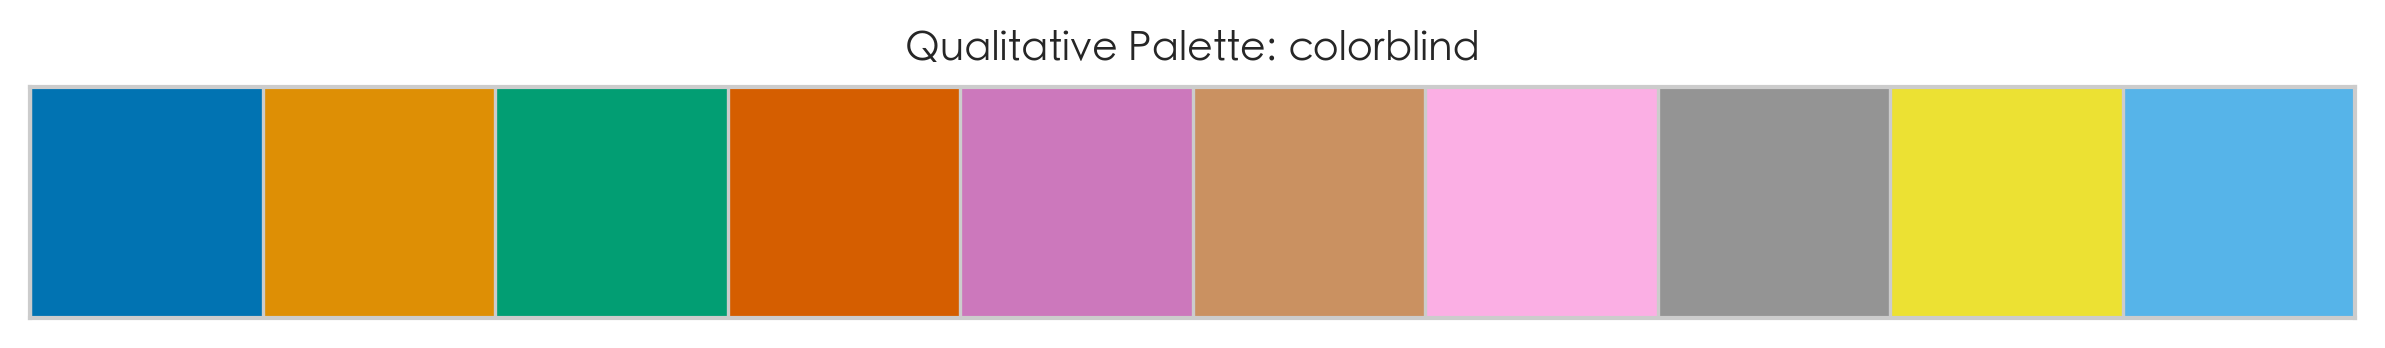

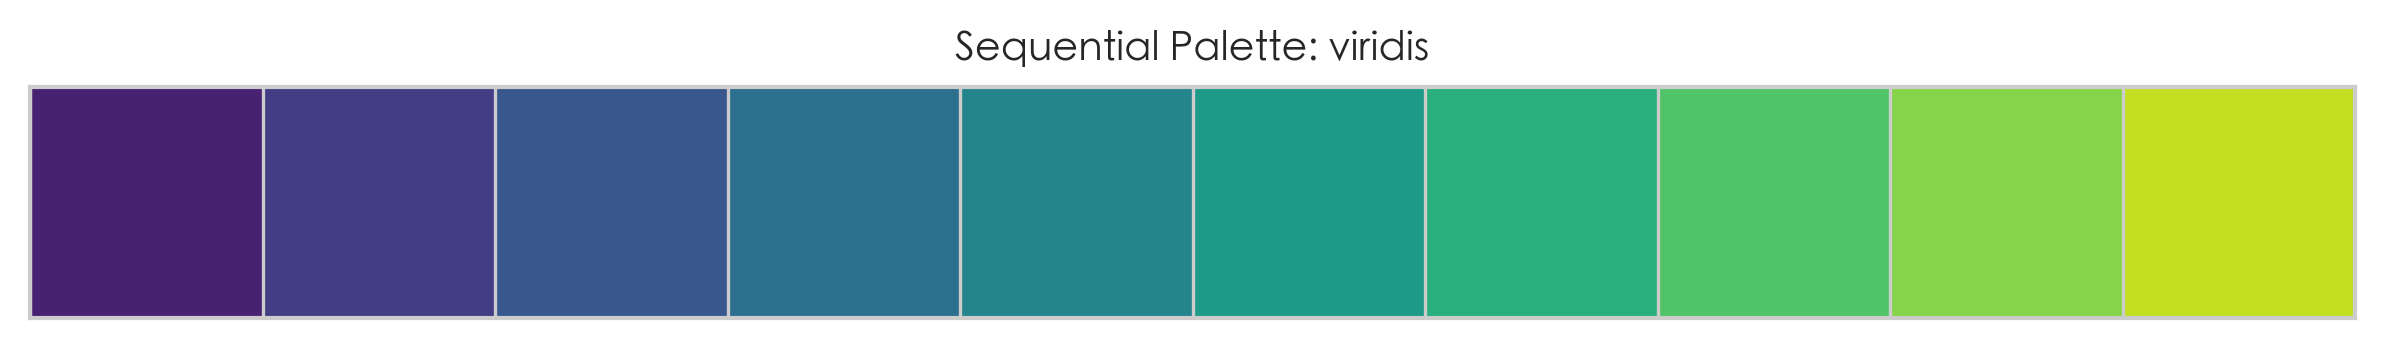

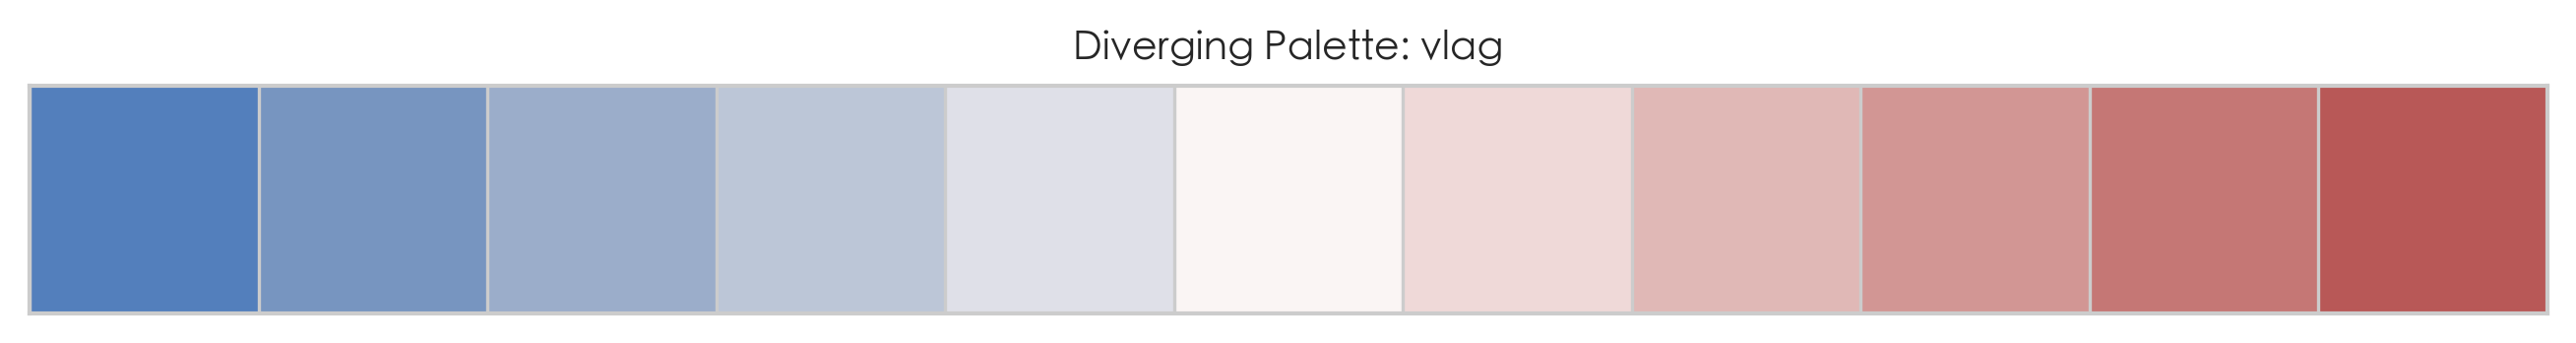

In [10]:
# 预览一个定性调色板
sns.palplot(sns.color_palette('colorblind'))
plt.title('Qualitative Palette: colorblind')
plt.show()

# 预览一个顺序调色板
sns.palplot(sns.color_palette('viridis', n_colors=10))
plt.title('Sequential Palette: viridis')
plt.show()

# 预览一个发散调色板
sns.palplot(sns.color_palette('vlag', n_colors=11))
plt.title('Diverging Palette: vlag')
plt.show()

In [11]:
# 样例数据
np.random.seed(0)
data = {
    'x_value': np.random.randn(200),
    'y_value': np.random.randn(200) + 2,
    'category': np.random.choice(['Group A', 'Group B'], 200),
    'time': np.arange(200)
}
df = pd.DataFrame(data)
df['y_value_correlated'] = df['x_value'] + np.random.randn(200) * 0.5

# 散点图

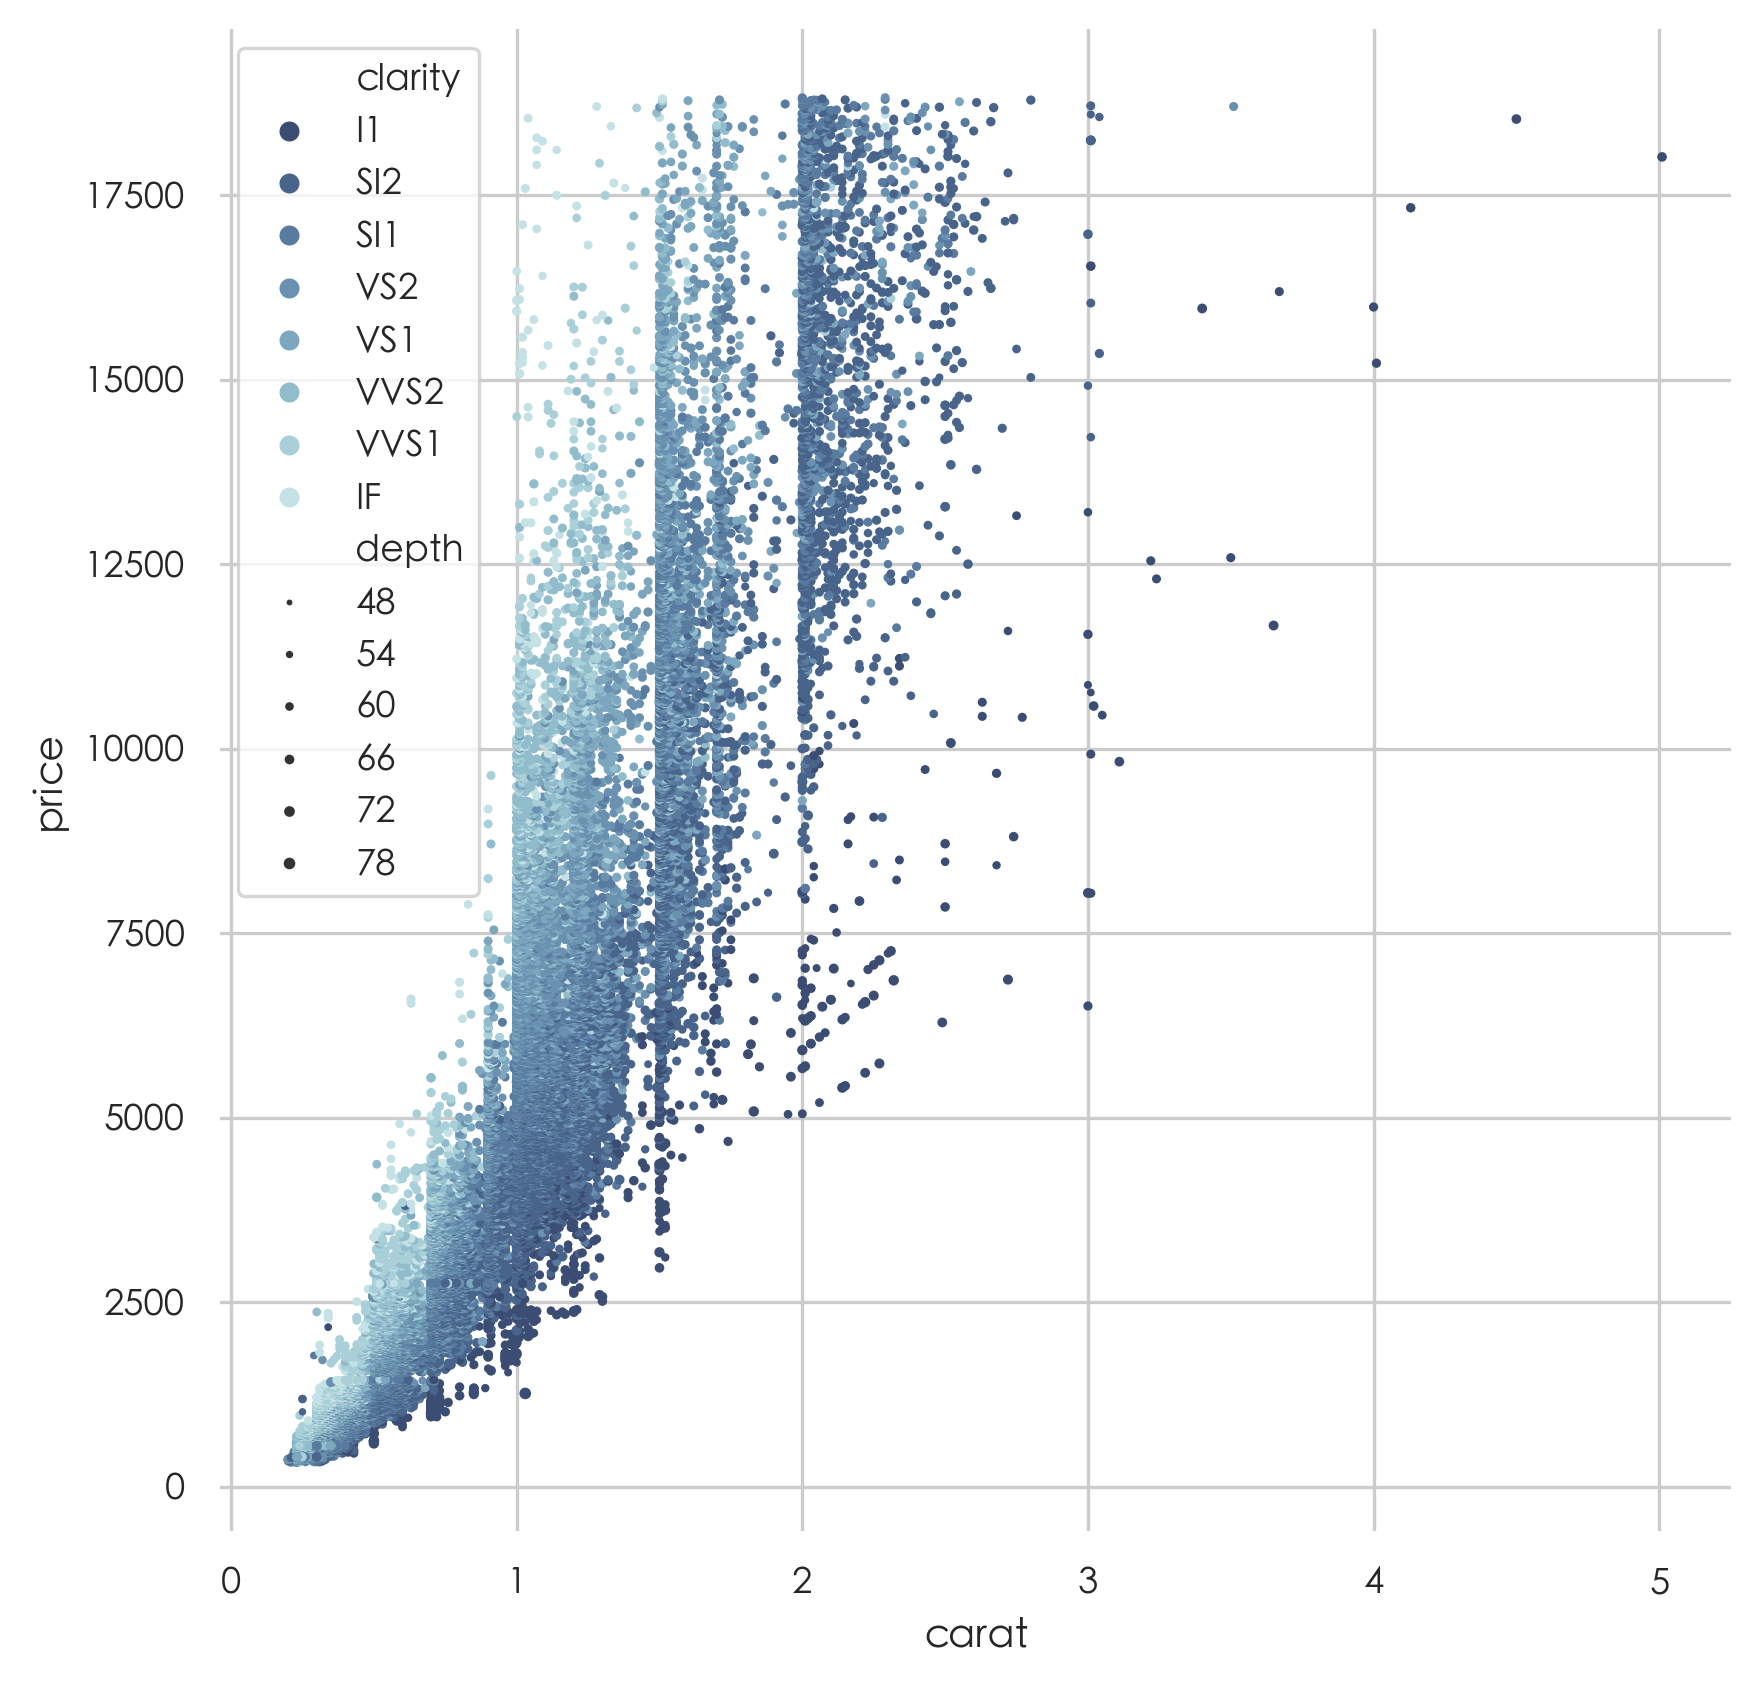

In [13]:
# 加载seaborn自带的示例数据集"diamonds"
diamonds = sns.load_dataset("diamonds")

# 创建一个Figure对象(f)和Axes对象(ax)，并设定尺寸
f, ax = plt.subplots(figsize=(6.5, 6.5))
# 移除图表的上、左、右、下边框线
sns.despine(f, left=True, bottom=True)
# 定义一个有逻辑顺序的列表，用于指定钻石净度的排序
clarity_ranking = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
sns.scatterplot(x="carat", y="price",
                hue="clarity", # hue（色调）参数将数据的另一个维度——净度（clarity）——映射到了数据点的颜色上
                size="depth",  # size（大小）参数将钻石的深度（depth）映射到了数据点的大小上
                palette="ch:r=-.2,d=.3_r",  # 动态创建了一个非常高级的 "cubehelix" 调色板
                hue_order=clarity_ranking,  # 在为 clarity 分配颜色时，不要按字母顺序，而是要严格按照我们之前定义的 clarity_ranking 列表（从差到好）的顺序
                                            # 确保颜色的渐变方向和净度的提升方向一致
                sizes=(1, 8), linewidth=0,  # 控制 size 映射的范围。它将 depth 值最小的点设置为1号大小，最大的点设置为8号大小，中间的值则按比例缩放
                data=diamonds, ax=ax)

# bbox_inches='tight' 确保图形的边界被紧密包裹,去除多余的空白区域
plt.savefig('diamonds_scatterplot.png', dpi=300, bbox_inches='tight')  # 保存图形
plt.savefig('diamonds_scatterplot.pdf', dpi=300, bbox_inches='tight')  # 保存图形为PDF格式
plt.show()  # 显示图形

# 线性回归图

```bash
Figure-level 函数（如 lmplot, relplot, displot, catplot）：
它们会自动创建整个图窗（Figure）以及可能包含的多个子图（sub-plots）。
你不需要预先创建画布，而是通过它自己的参数（如col,row）来控制整个图表的结构。

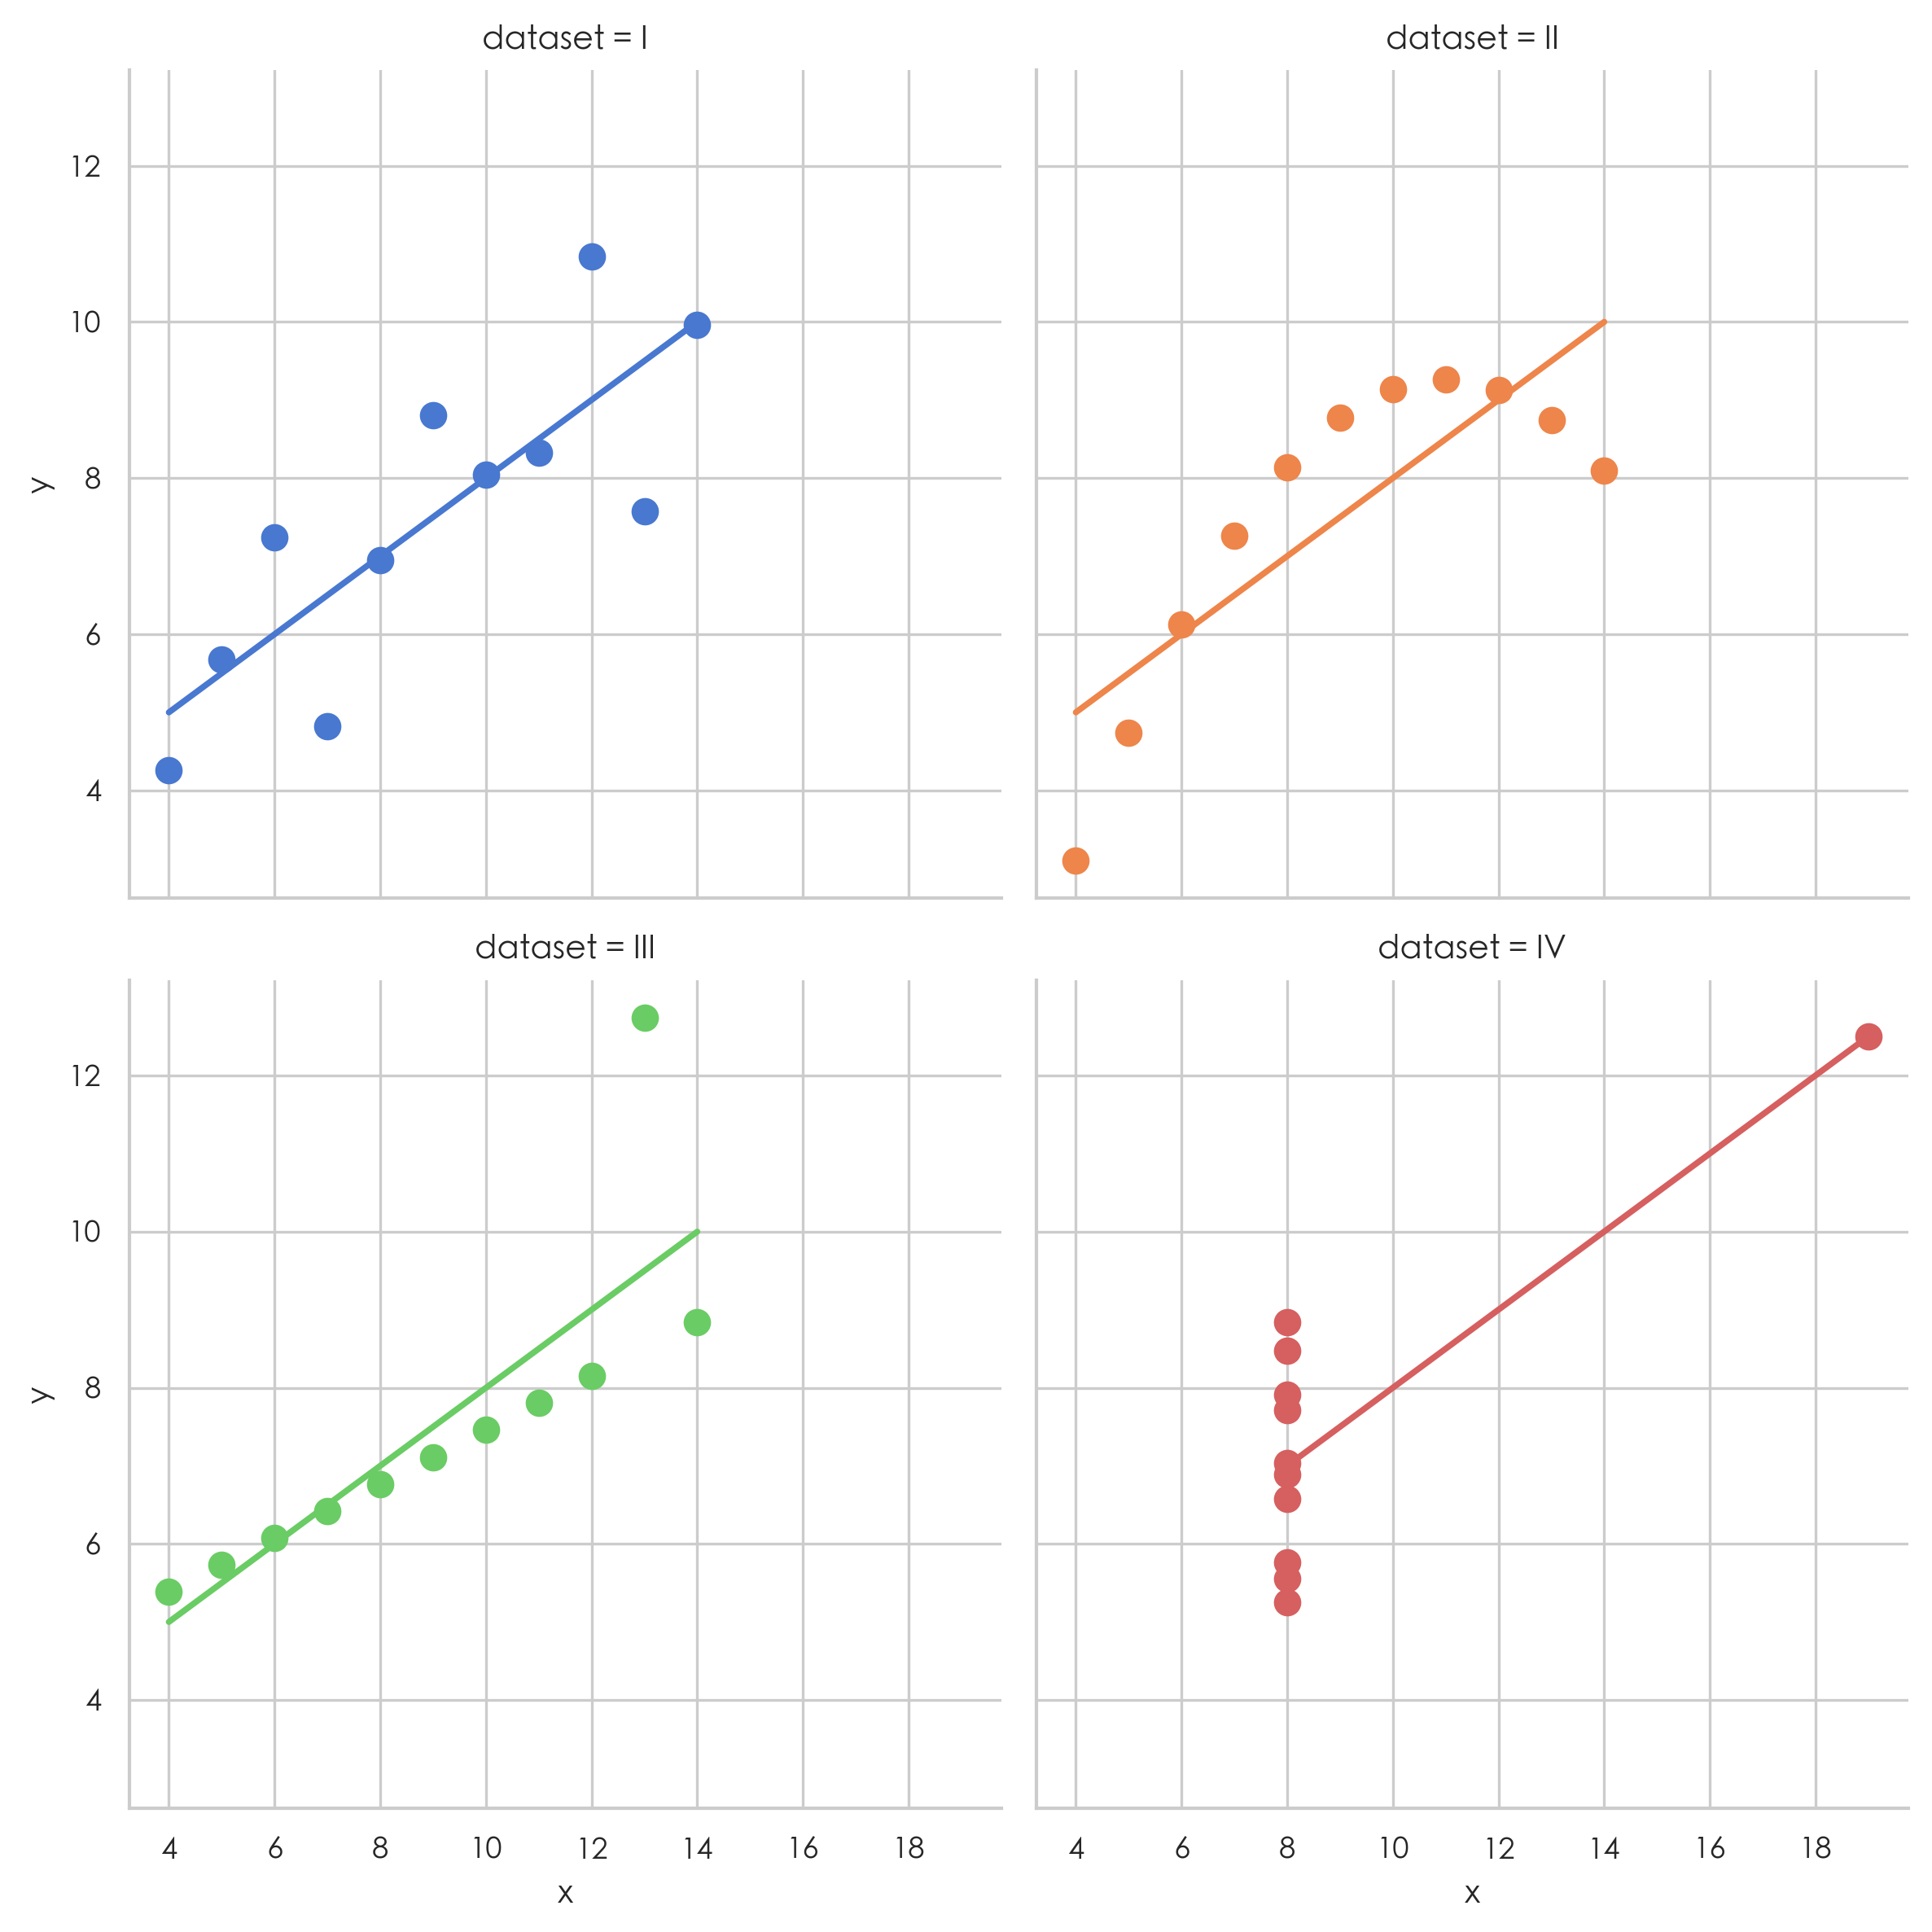

In [ ]:
df = sns.load_dataset("anscombe")
# Show the results of a linear regression within each dataset
sns.lmplot(
    data=df, x="x", y="y", 
    col="dataset", # 分面绘图，按数据集分列，为每个类别单独创建一个子图
    hue="dataset", # 使用数据集名称作为色调，给每个子图的点上色
    col_wrap=2,    # 每行最多放2个子图
    palette="muted",  # 定性调色板
    ci=None,    # ci 代表置信区间，默认情况下 (ci=95)，lmplot 会在回归线的周围绘制一个半透明的带状区域，来表示拟合的不确定性
    height=4,   # 控制每个子图的高度（单位是英寸）
    scatter_kws={"s": 50, "alpha": 1}   # 散点图的样式参数，s=50 设置点的大小，alpha=1 设置点的透明度为不透明
)

# 多类别时序图

<Axes: xlabel='timepoint', ylabel='signal'>

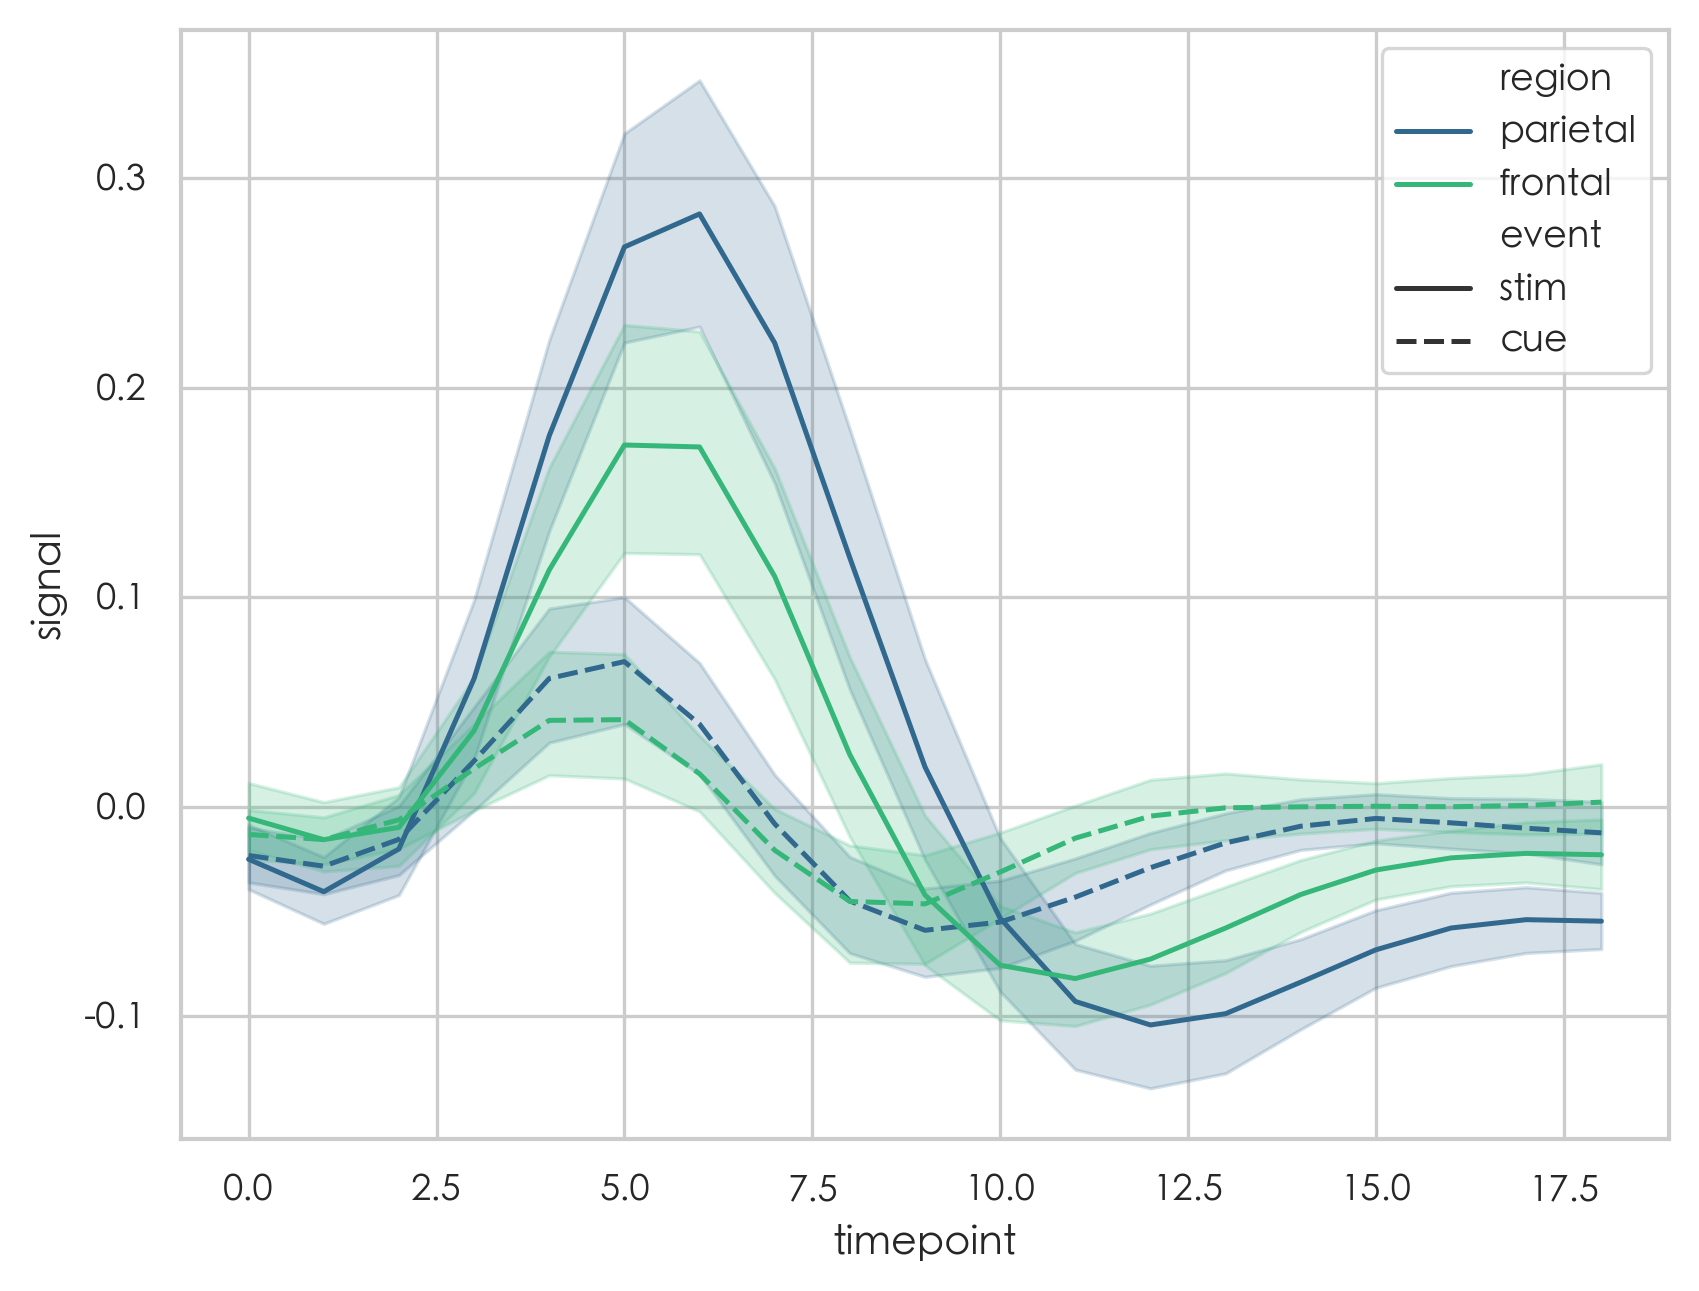

In [24]:
# Load an example dataset with long-form data
fmri = sns.load_dataset("fmri")

# Plot the responses for different events and regions
sns.lineplot(x="timepoint",    # x轴数据为时间点
             y="signal",       # y轴数据为信号强度
             hue="region",     # 色调数据为大脑区域
             style="event",    # 线条样式数据为事件类型
             palette="viridis",  # 使用 colorblind 调色板
             data=fmri)

# 分面直方图

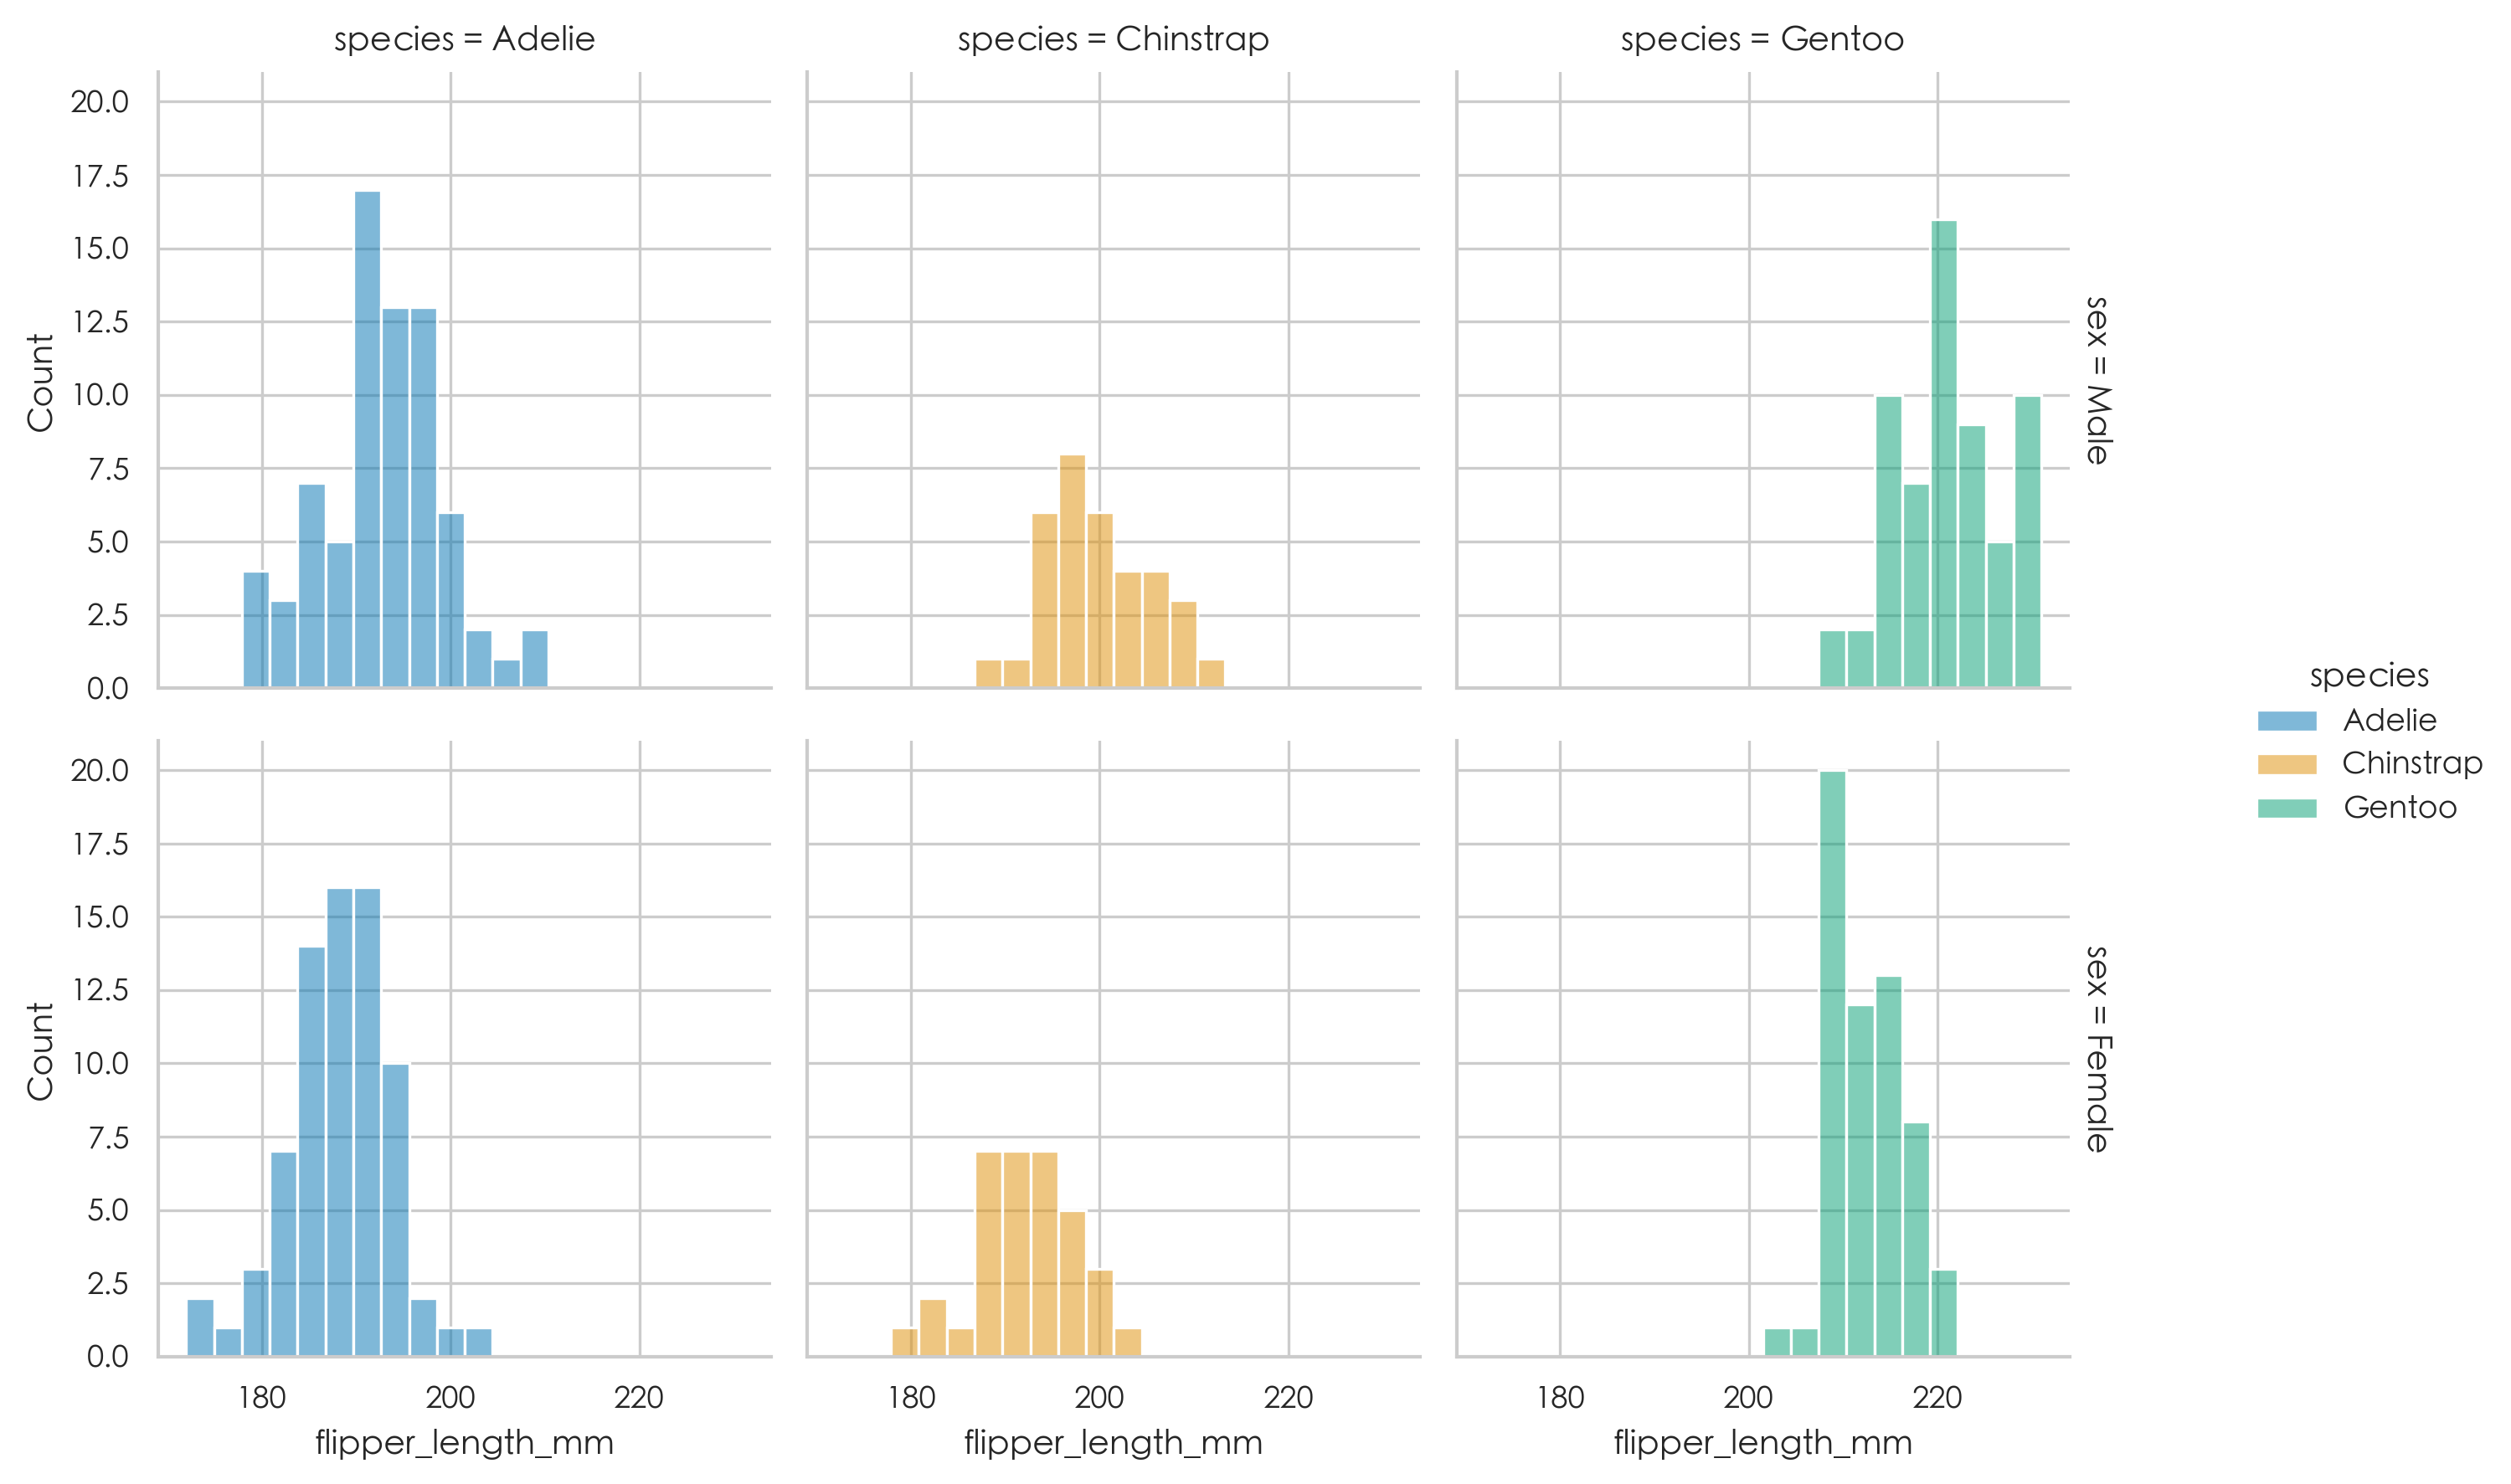

In [27]:
df = sns.load_dataset("penguins")
sns.displot(
    df, 
    x="flipper_length_mm",  # x轴数据为企鹅的鳍长 
    col="species",  # 为每个物种单独创建一个子图列
    row="sex",  # 为每个性别单独创建一个子图行
    hue="species",  # 使用物种作为色调，给每个子图的点上色
    palette="colorblind",  # 使用 colorblind 调色板
    binwidth=3, # 设置直方图的条宽为3毫米
    height=3,   # 设置每个子图的高度为3英寸
    facet_kws=dict(margin_titles=True),    # 将子图的标题移动到网格的边缘
    kind="hist",  # 指定绘图类型为直方图,默认
)

# 关系图

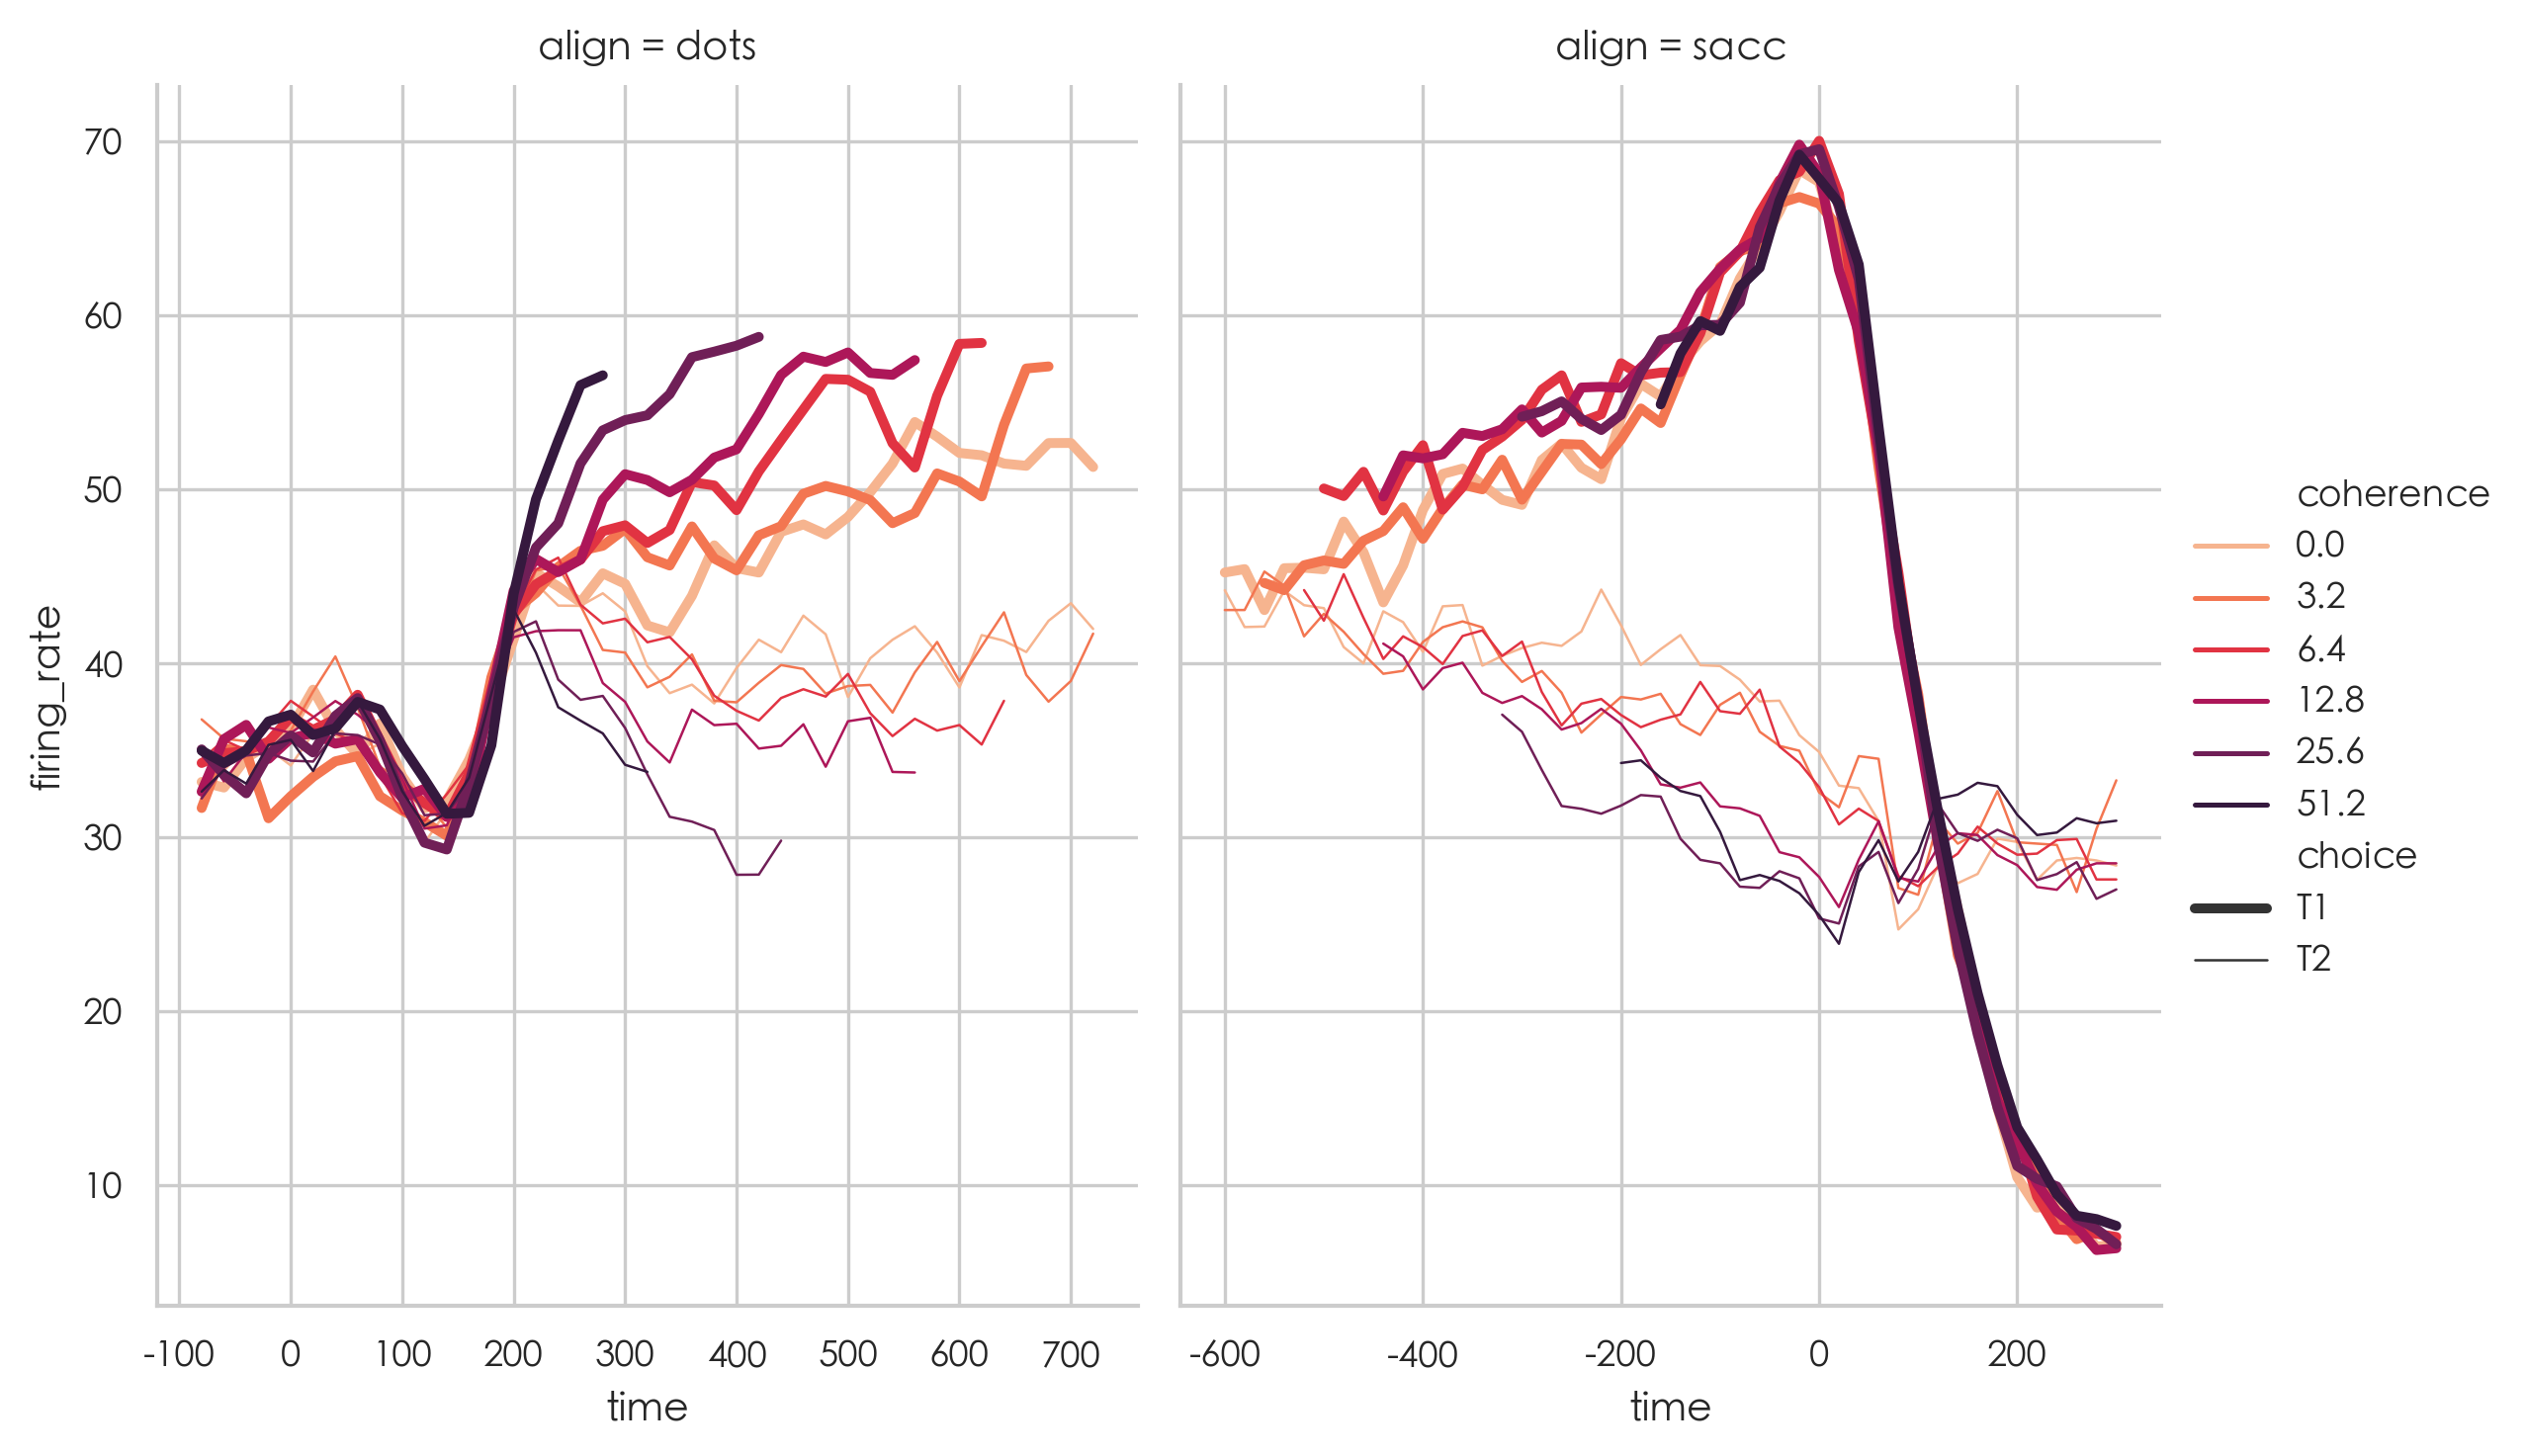

In [ ]:
dots = sns.load_dataset("dots")

# 自定义调色板
palette = sns.color_palette("rocket_r")

# Plot the lines on two facets
sns.relplot(    # relationship plot
    data=dots,
    x="time",   # x轴数据为时间 
    y="firing_rate",    # y轴数据为神经元的放电率
    hue="coherence",    # 色调数据为相干性
    size="choice",      # 线条大小数据为选择
    col="align",        # 为每个对齐方式单独创建一个子图列
    kind="line",        # 指定绘图类型为线图，默认为散点图
    size_order=["T1", "T2"],    # 设置线条大小的顺序
    palette=palette,
    height=5,           # 设置每个子图的高度为5英寸
    aspect=.75,         # 设置每个子图的宽高比为0.75
    facet_kws=dict(sharex=False),   # sharex=False 每个子图的x轴不共享
)

# 分组条形图

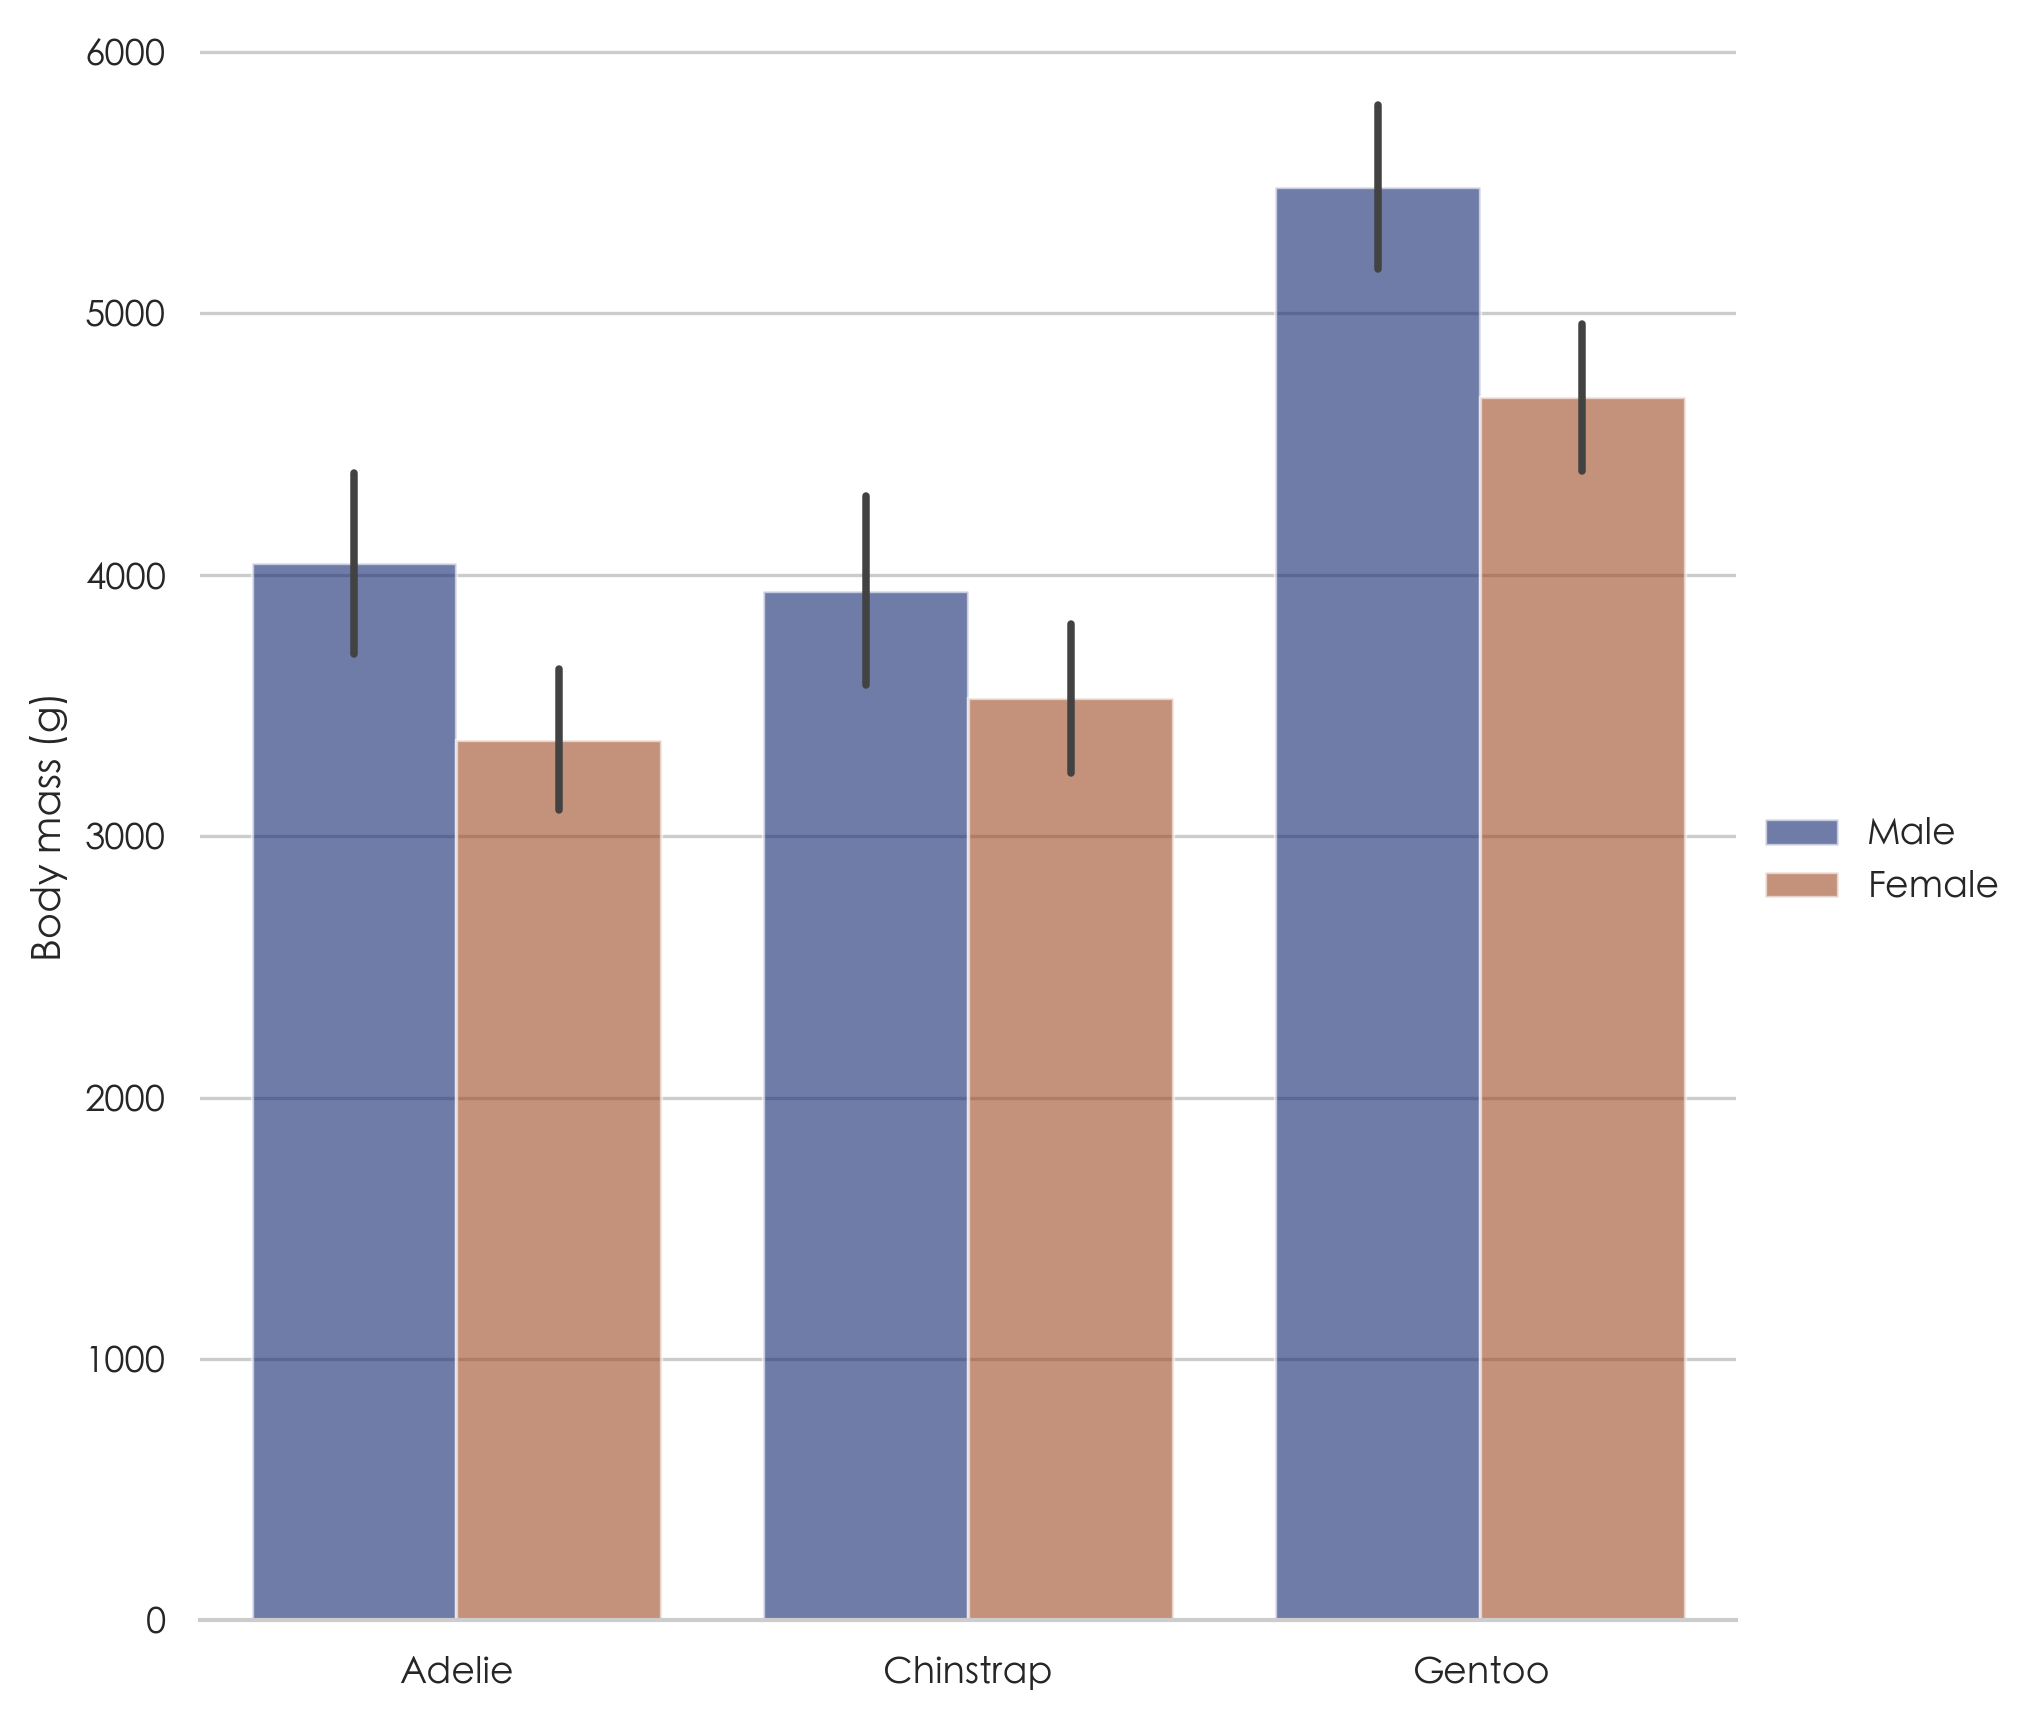

In [31]:
penguins = sns.load_dataset("penguins")

# Draw a nested barplot by species and sex
g = sns.catplot(    # categorical plot 分类图
    data=penguins, 
    kind="bar",
    x="species", 
    y="body_mass_g", 
    hue="sex",
    # 通过误差棒展示数据的标准差 
    errorbar="sd",  # 使用标准差作为误差条
    # errorbar="se",  # 使用标准误差作为误差条
    palette="dark", 
    alpha=.6, 
    height=6
)
g.despine(left=True)    # 移除左边框
g.set_axis_labels("", "Body mass (g)")  # 设置 FacetGrid 对象坐标轴标签
g.legend.set_title("")  # 设置图例标题为空

# 分组箱形图

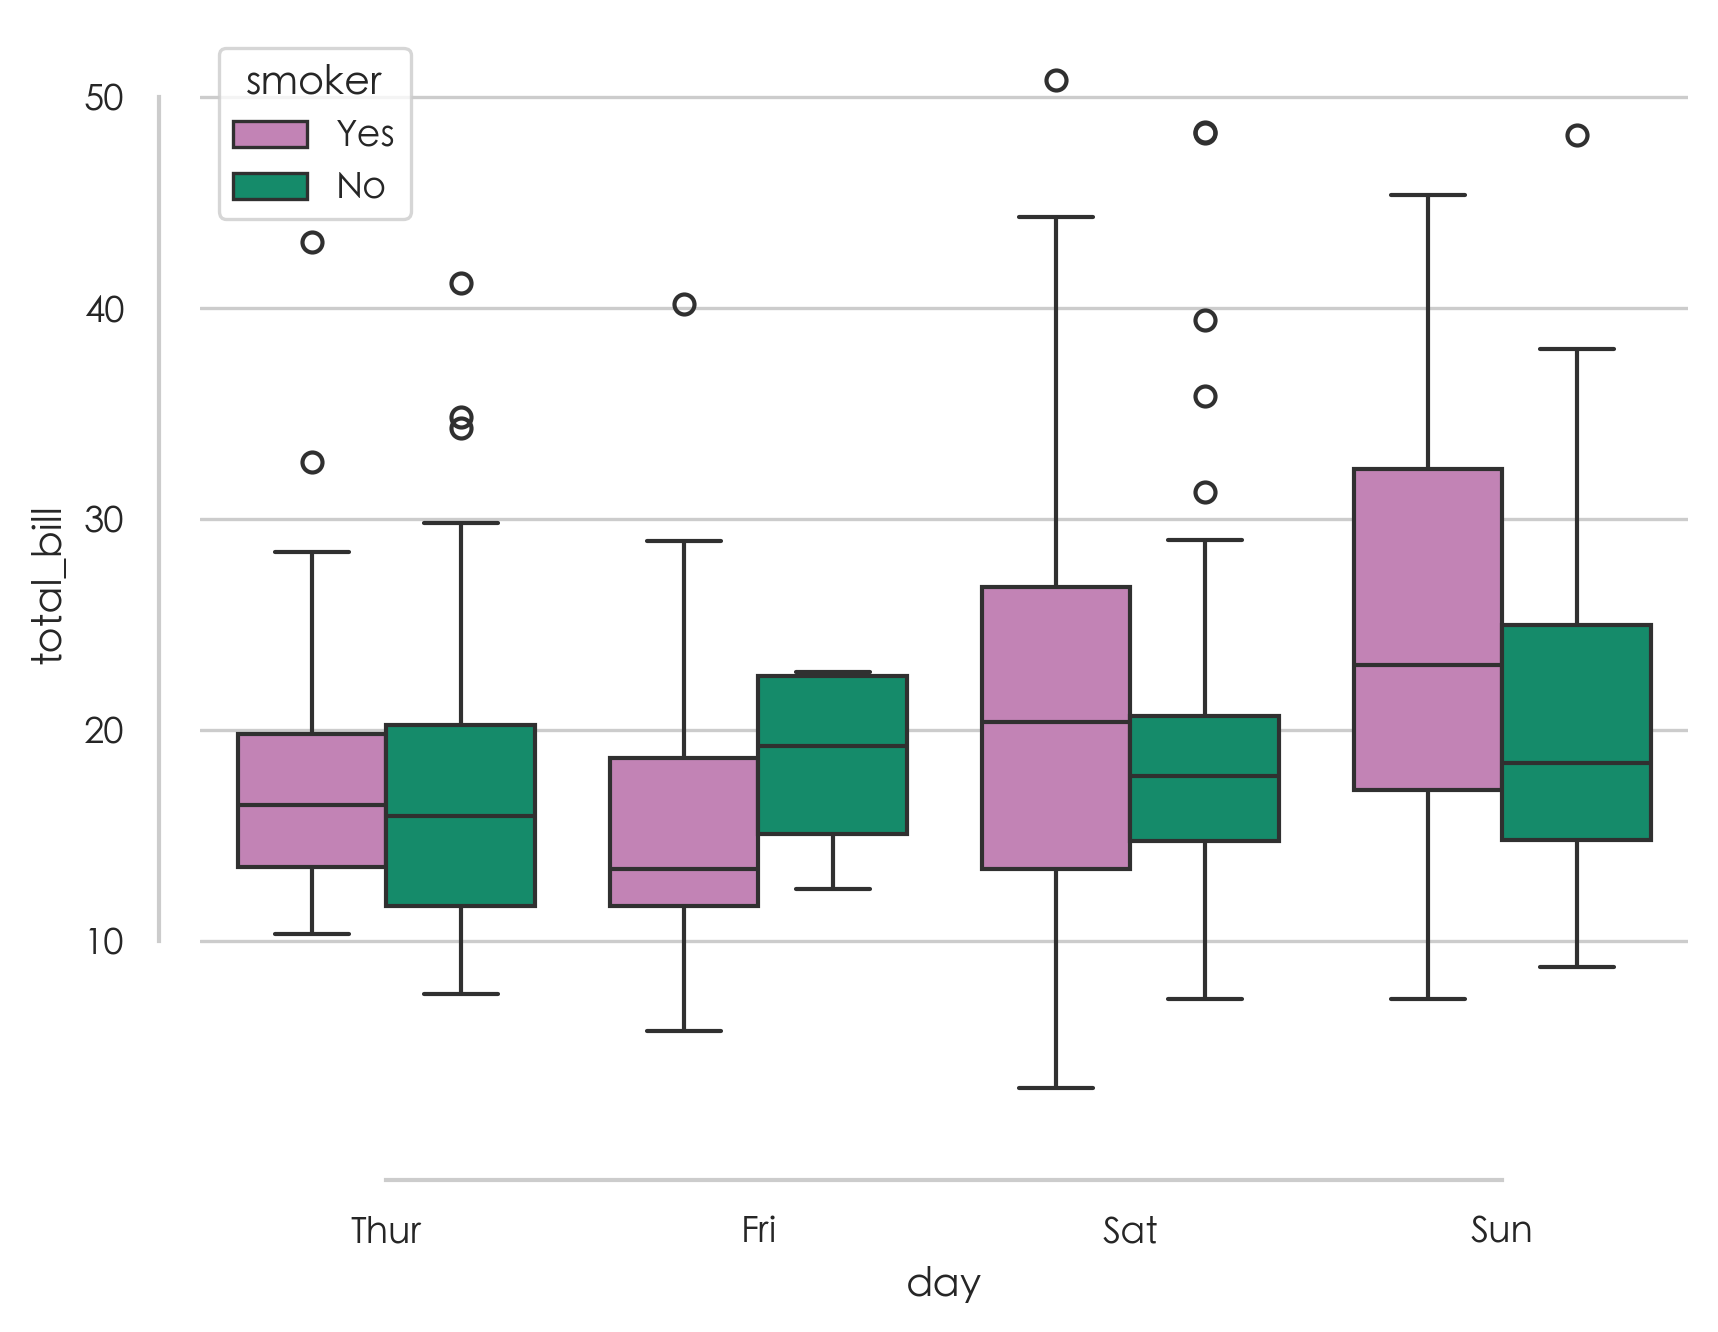

In [ ]:
# Load the example tips dataset
tips = sns.load_dataset("tips")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="day", 
            y="total_bill",
            hue="smoker", 
            palette=["m", "g"],     # "m" 是洋红色 (magenta) 
                                    # "g" 是绿色 (green) 
            data=tips)
# 悬浮坐标轴
# sns.despine(): 默认移除顶部和右侧的边框线
sns.despine(offset=10,      # 在数据和坐标轴之间创造一个偏移量
            trim=True)      # 裁剪坐标轴的范围，使其长度与该轴上刻度的范围完全匹配

<Axes: xlabel='day', ylabel='total_bill'>

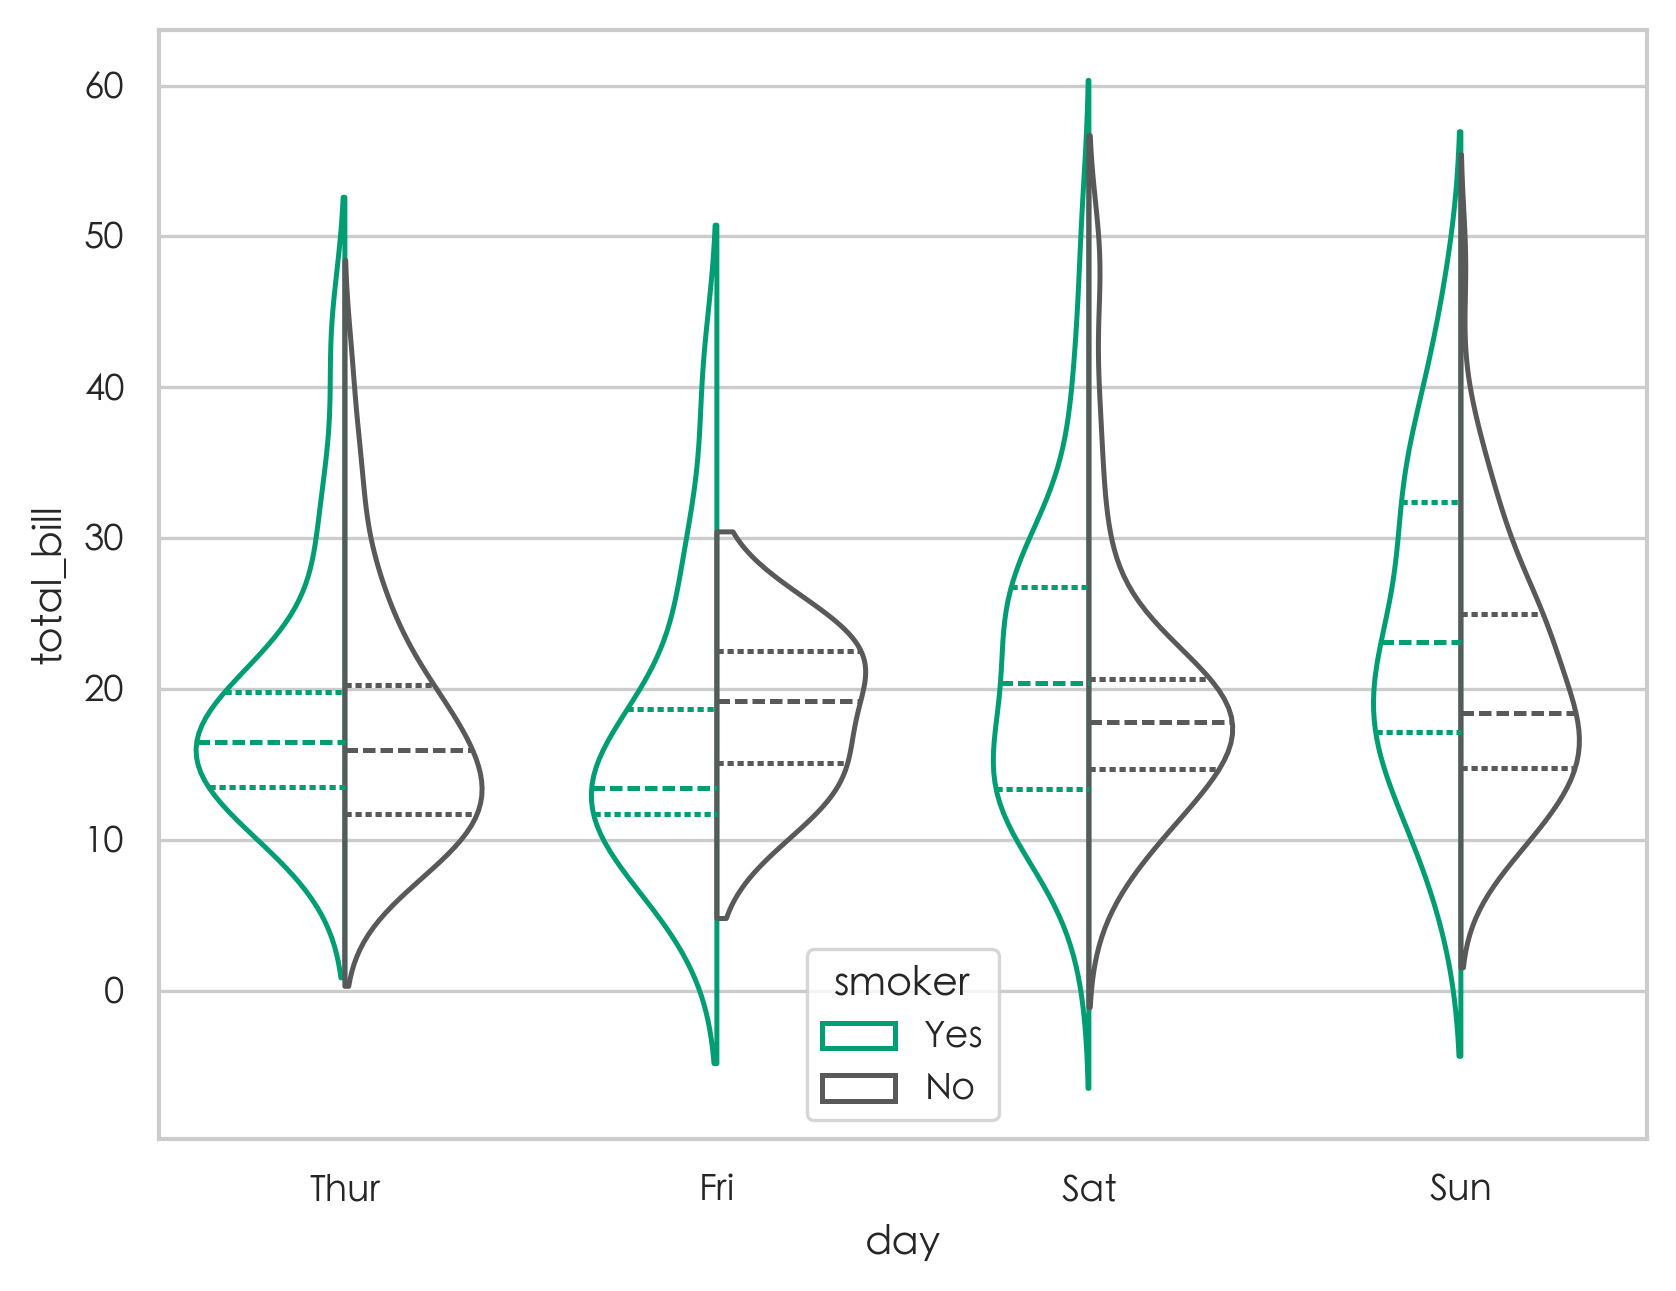

In [ ]:
# Load the example tips dataset
tips = sns.load_dataset("tips")

# Draw a nested violinplot and split the violins for easier comparison
sns.violinplot(data=tips, x="day", y="total_bill", hue="smoker",
               # 将这两个小提琴（类别）从中间劈开，然后拼成一个
               split=True,  # 这个参数只有在 hue 变量恰好只有两个类别时才能生效
               inner="quart",   # 用来指定内部的标记样式，绘制四分位数线
               fill=False,      # 取消填充
               palette={"Yes": "g", "No": ".35"})   # ".35" 代表一个灰度值（0=黑, 1=白）
                                                    # 所以 .35 是一种深灰色

# 散点热力图

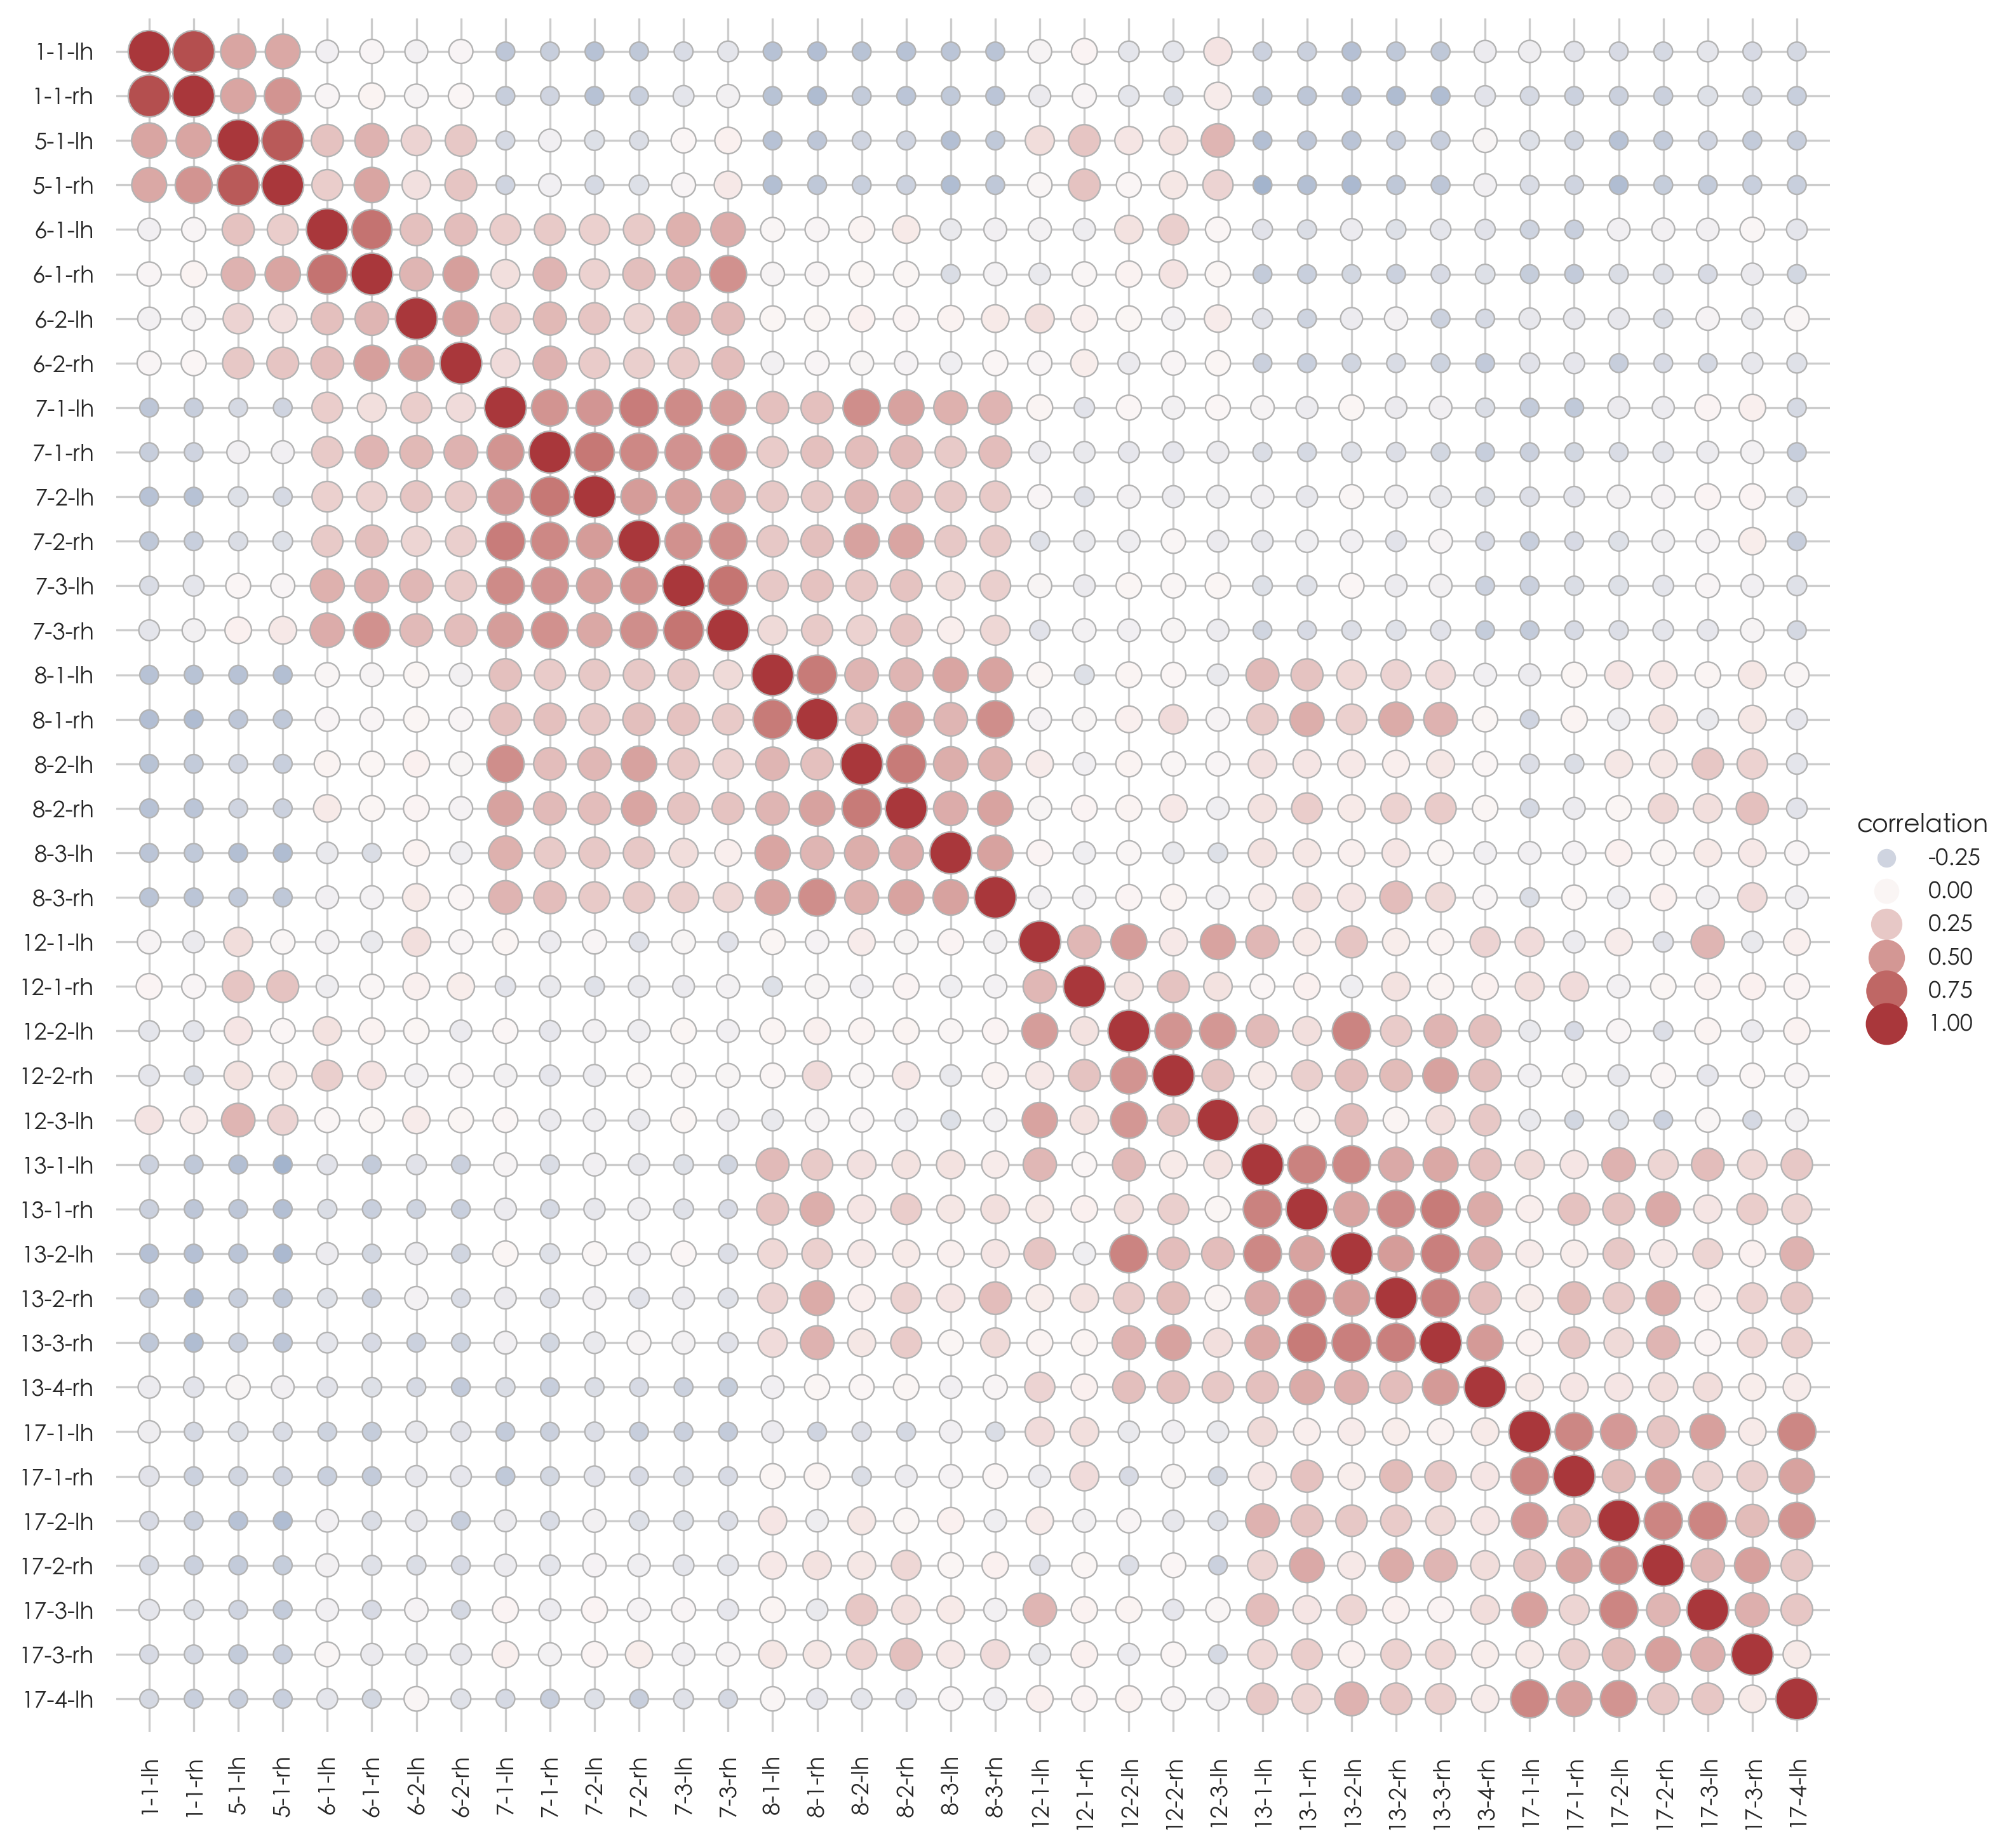

In [ ]:
# Load the brain networks dataset, select subset, and collapse the multi-index
df = sns.load_dataset("brain_networks", header=[0, 1, 2], index_col=0)
# 筛选部分数据用于展示
used_networks = [1, 5, 6, 7, 8, 12, 13, 17]
used_columns = (df.columns
                  .get_level_values("network")
                  .astype(int)
                  .isin(used_networks))
df = df.loc[:, used_columns]
# 将多层级的列名合并成单一的字符串，如 "1-1"
df.columns = df.columns.map("-".join)

# Compute a correlation matrix and convert to long-form
# 将宽格式相关性矩阵“溶解”并“重塑”为长格式数据列表
# .stack() 将 DataFrame 的列转换为行，形成一个多层索引的 Series
# reset_index(name="correlation") 将多层索引转换为 DataFrame，并将相关性值命名为 "correlation"
corr_mat = df.corr().stack().reset_index(name="correlation")

# Draw each cell as a scatter point with varying size and color
g = sns.relplot(
    data=corr_mat,
    x="level_0", y="level_1", hue="correlation", size="correlation",
    palette="vlag", 
    hue_norm=(-1, 1),   # 校准颜色映射范围 
    edgecolor=".7",     # 给每个散点加上一个浅灰色描边，增加质感和区分度
    height=10, 
    sizes=(50, 250),    # 设置散点的最小和最大尺寸
    size_norm=(-.2, .8),    # 校准大小映射范围
)

# Tweak the figure to finalize
g.set(xlabel="", ylabel="", aspect="equal")     # aspect="equal" 确保 x 和 y 轴的比例相同
g.despine(left=True, bottom=True)   # 移除所有边框线
g.ax.margins(.02)       # 增加 x 和 y 轴的边距，使得散点不会紧贴坐标轴

# 设置 x 轴标签的旋转角度为 90 度
for label in g.ax.get_xticklabels():
    label.set_rotation(90)

# 六边形箱体图

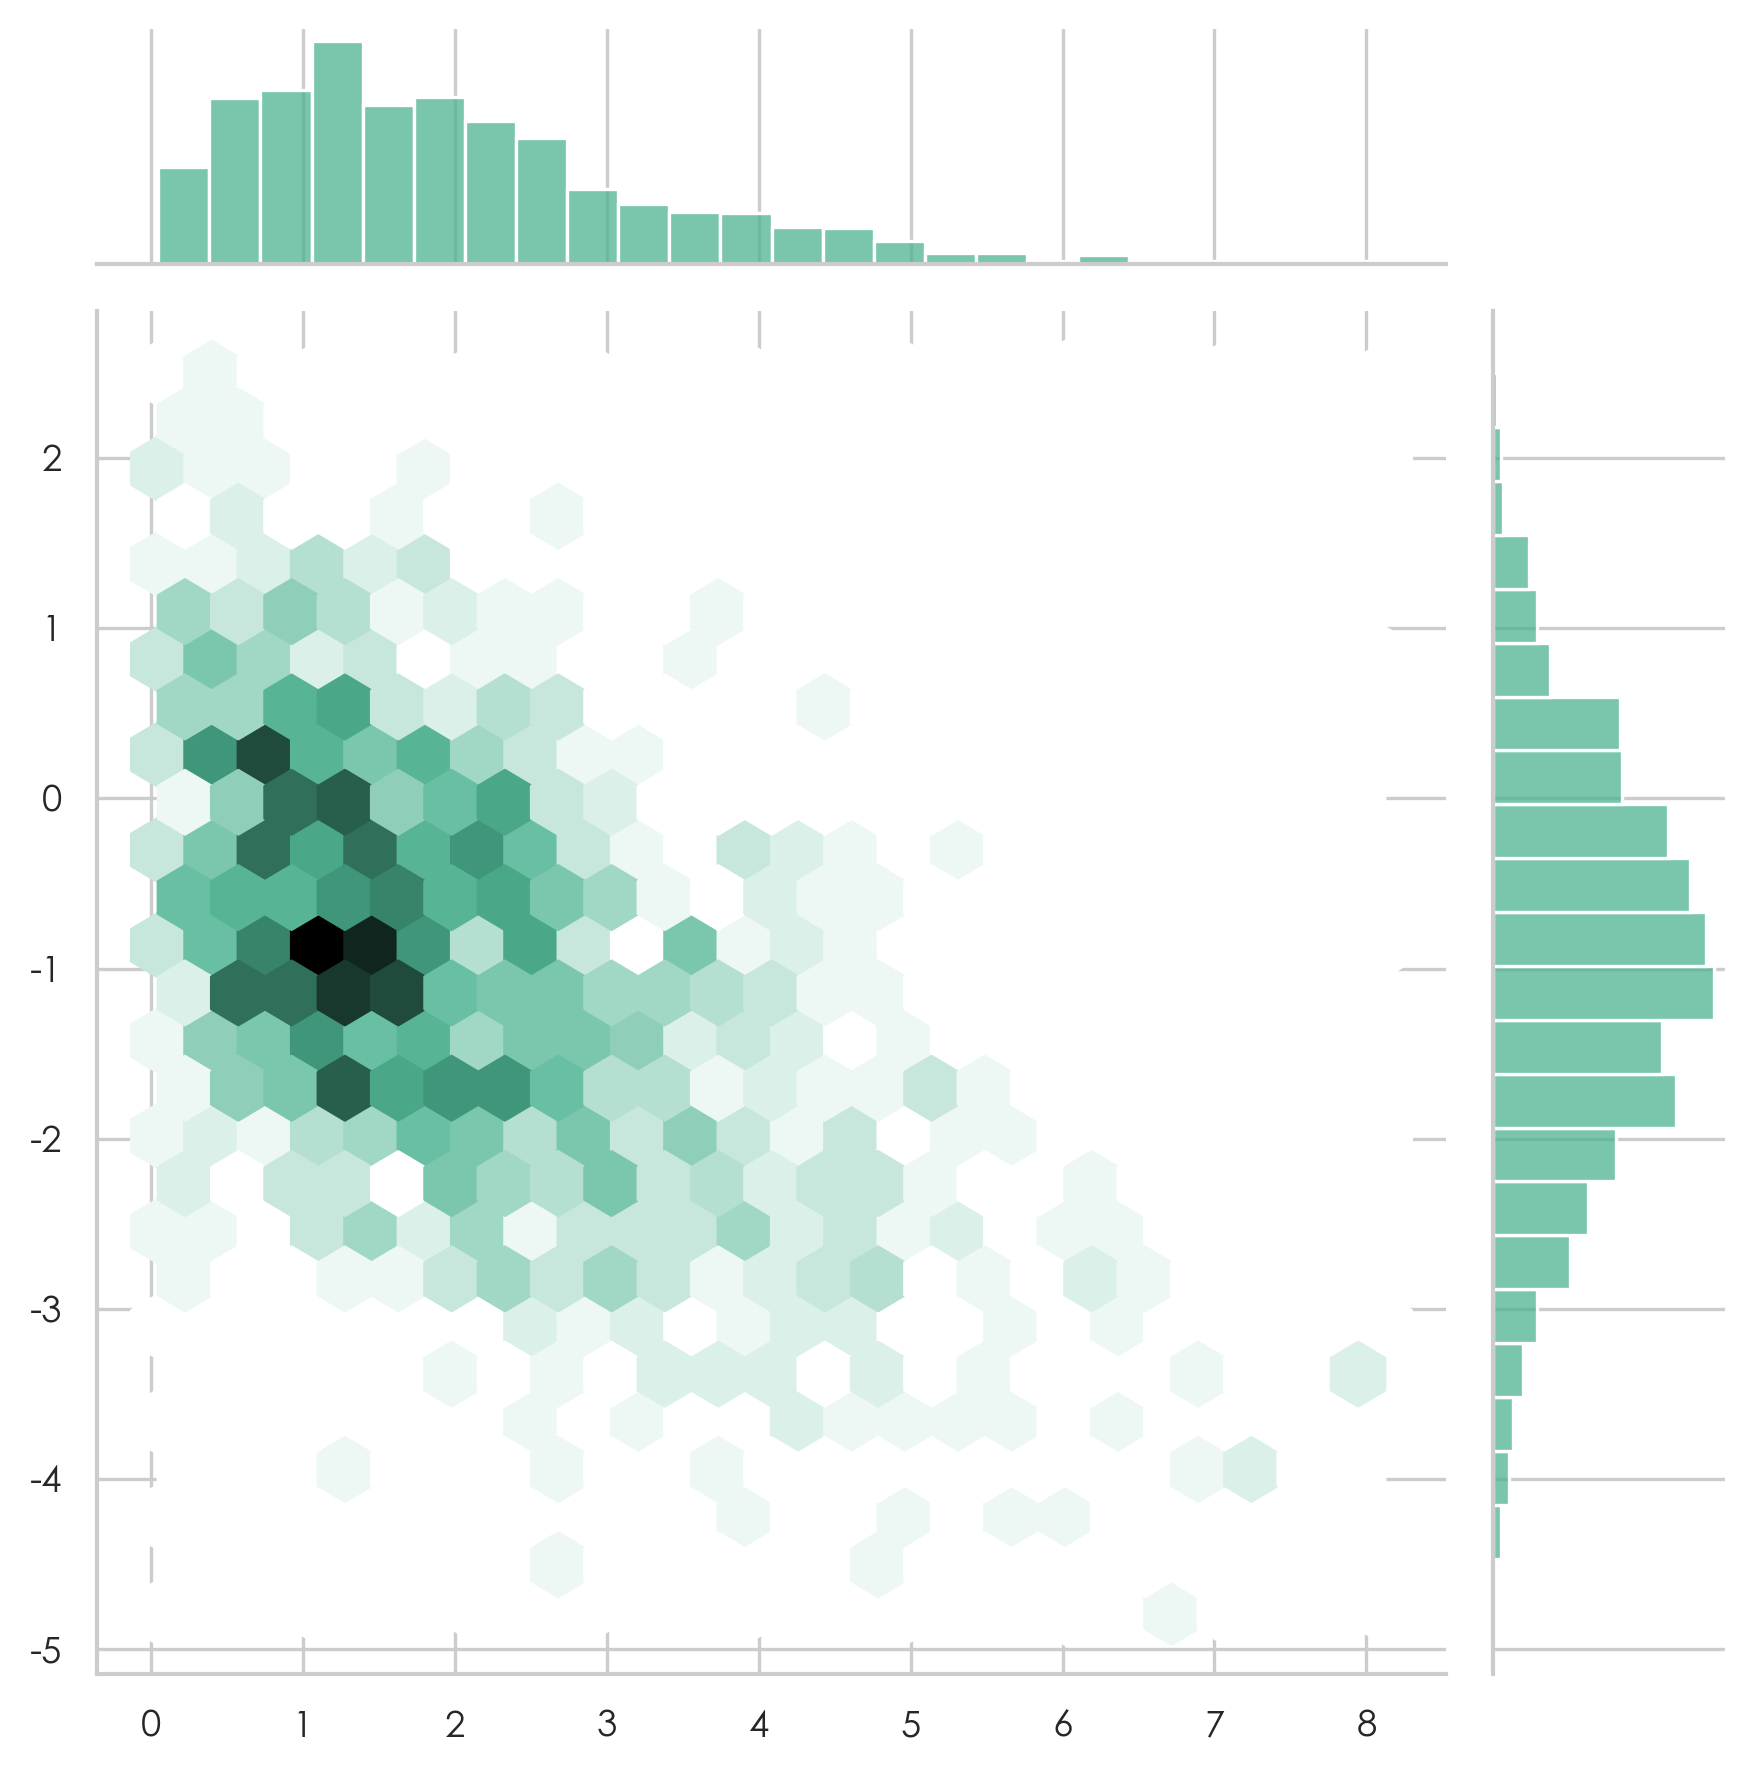

In [ ]:
rs = np.random.RandomState(11)
x = rs.gamma(2, size=1000)
y = -.5 * x + rs.normal(size=1000)
# y 和 x 之间存在一定的负相关关系

# 解决数据点的“过载（overplotting）”问题
sns.jointplot(x=x, y=y, 
              kind="hex",   # hex 指 "hexagonal"六边形
              # 用颜色的深浅来表示数据的密度
              color="#4CB391")

# 堆叠直方图

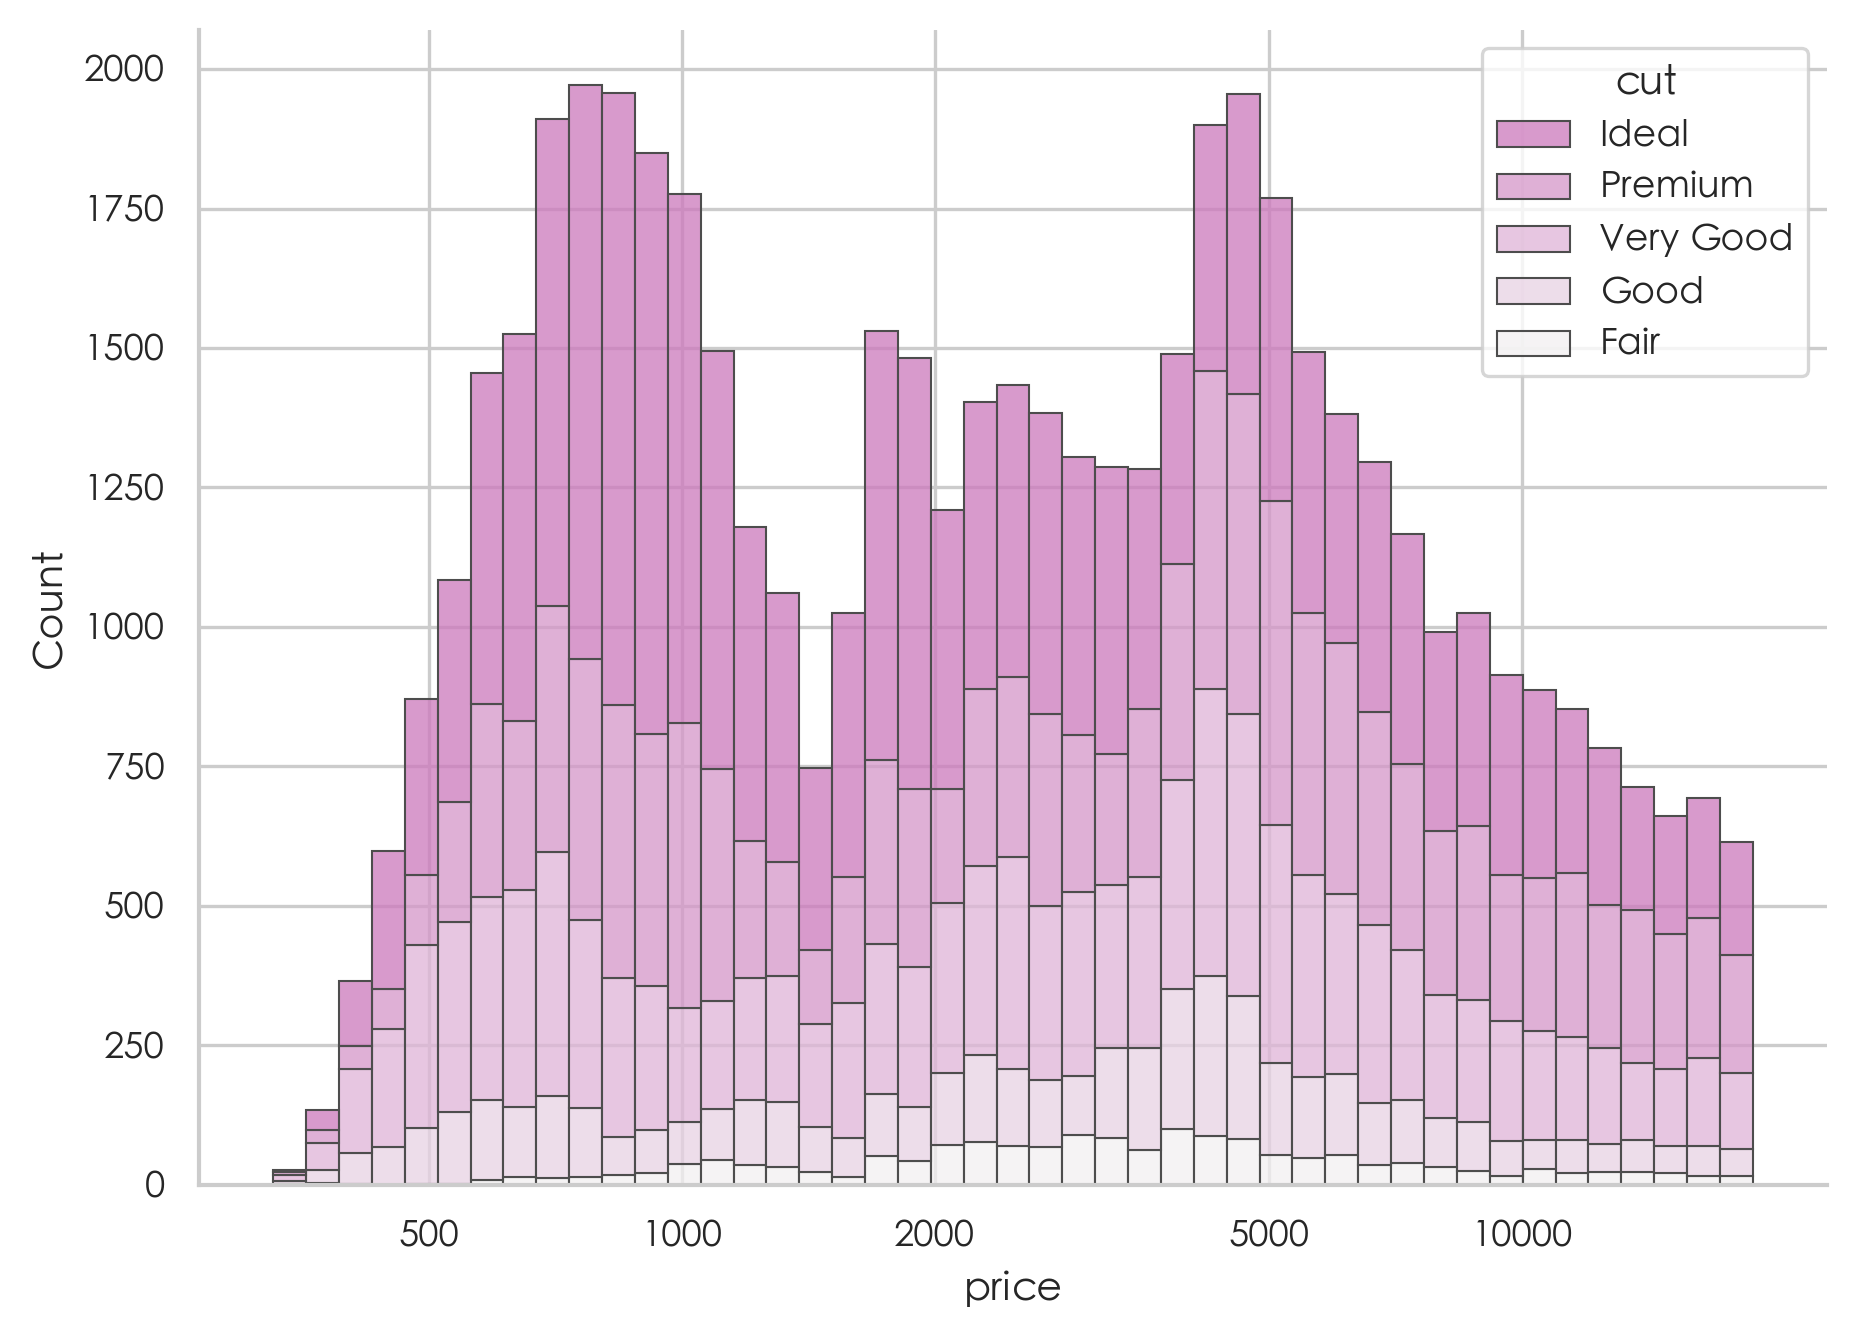

In [ ]:
diamonds = sns.load_dataset("diamonds")

f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    diamonds,
    x="price", 
    hue="cut",
    multiple="stack",   # 根据 hue 参数的值将直方图堆叠在一起
    palette="light:m_r",
    edgecolor=".3",     # 给直方图的条形加上一个浅灰色描边，增加质感和区分度
    linewidth=.5,
    log_scale=True,     # 设置 x 轴为对数刻度
    # 在使用对数坐标轴时，Matplotlib 默认可能会将刻度标签显示为科学计数法
)
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())  # 强制将刻度标签显示为我们日常习惯的普通数字
ax.set_xticks([500, 1000, 2000, 5000, 10000])   # 手动指定X轴上刻度线出现的位置

# 水平箱形图

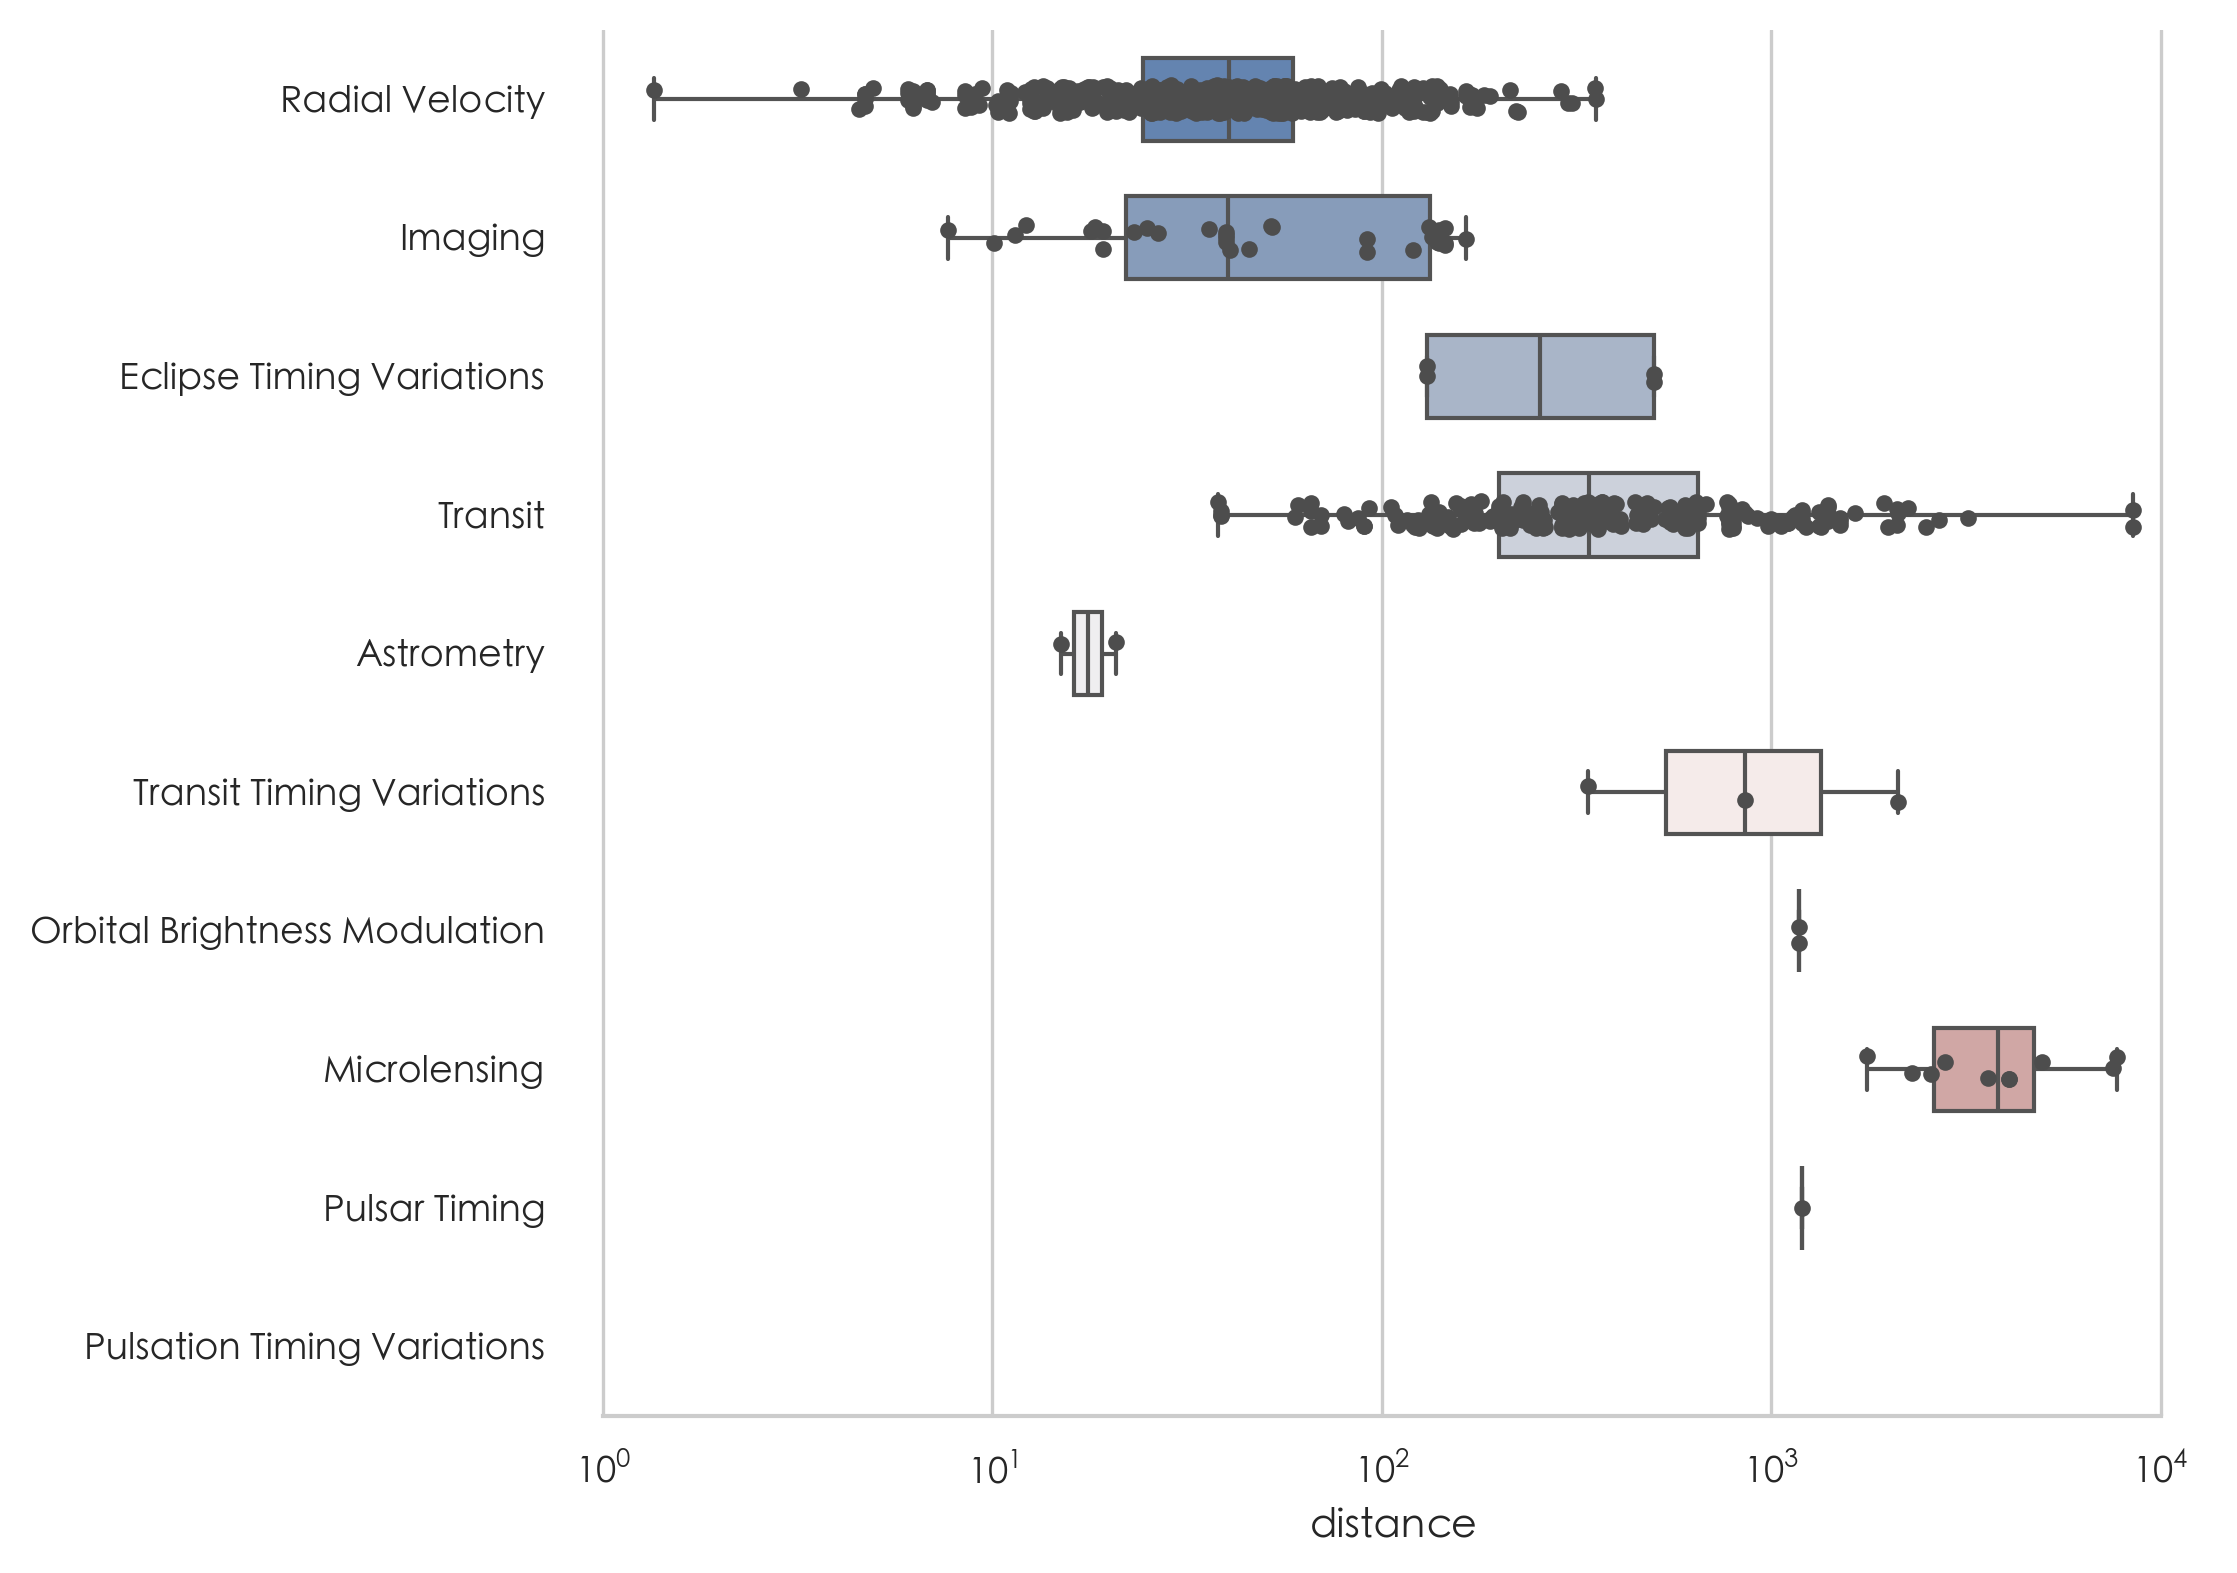

In [ ]:
# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
# 设置 x 轴为对数刻度
ax.set_xscale("log")

# Load the example planets dataset
planets = sns.load_dataset("planets")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    planets, x="distance", y="method", hue="method",
    whis=[0, 100],  # 让触须直接延伸到数据的最小值和最大值
    width=.6,   # 控制箱体的宽度
    palette="vlag"
)

# Add in points to show each observation
# 叠加散点图 
# sns.stripplot: 这是一种一维的散点图，它会将每个类别的数据点沿着其对应的轴线展开
sns.stripplot(planets, x="distance", y="method", size=4, color=".3")

# Tweak the visual presentation
ax.xaxis.grid(True)  # 在X轴上添加垂直网格线，方便在对数尺度上读数
ax.set(ylabel="")   # 清除y轴标签
sns.despine(trim=True, left=True)
# trim=True 的作用是裁剪（trim）坐标轴线，使其长度与该轴上刻度的范围完全匹配

# 标注散点图

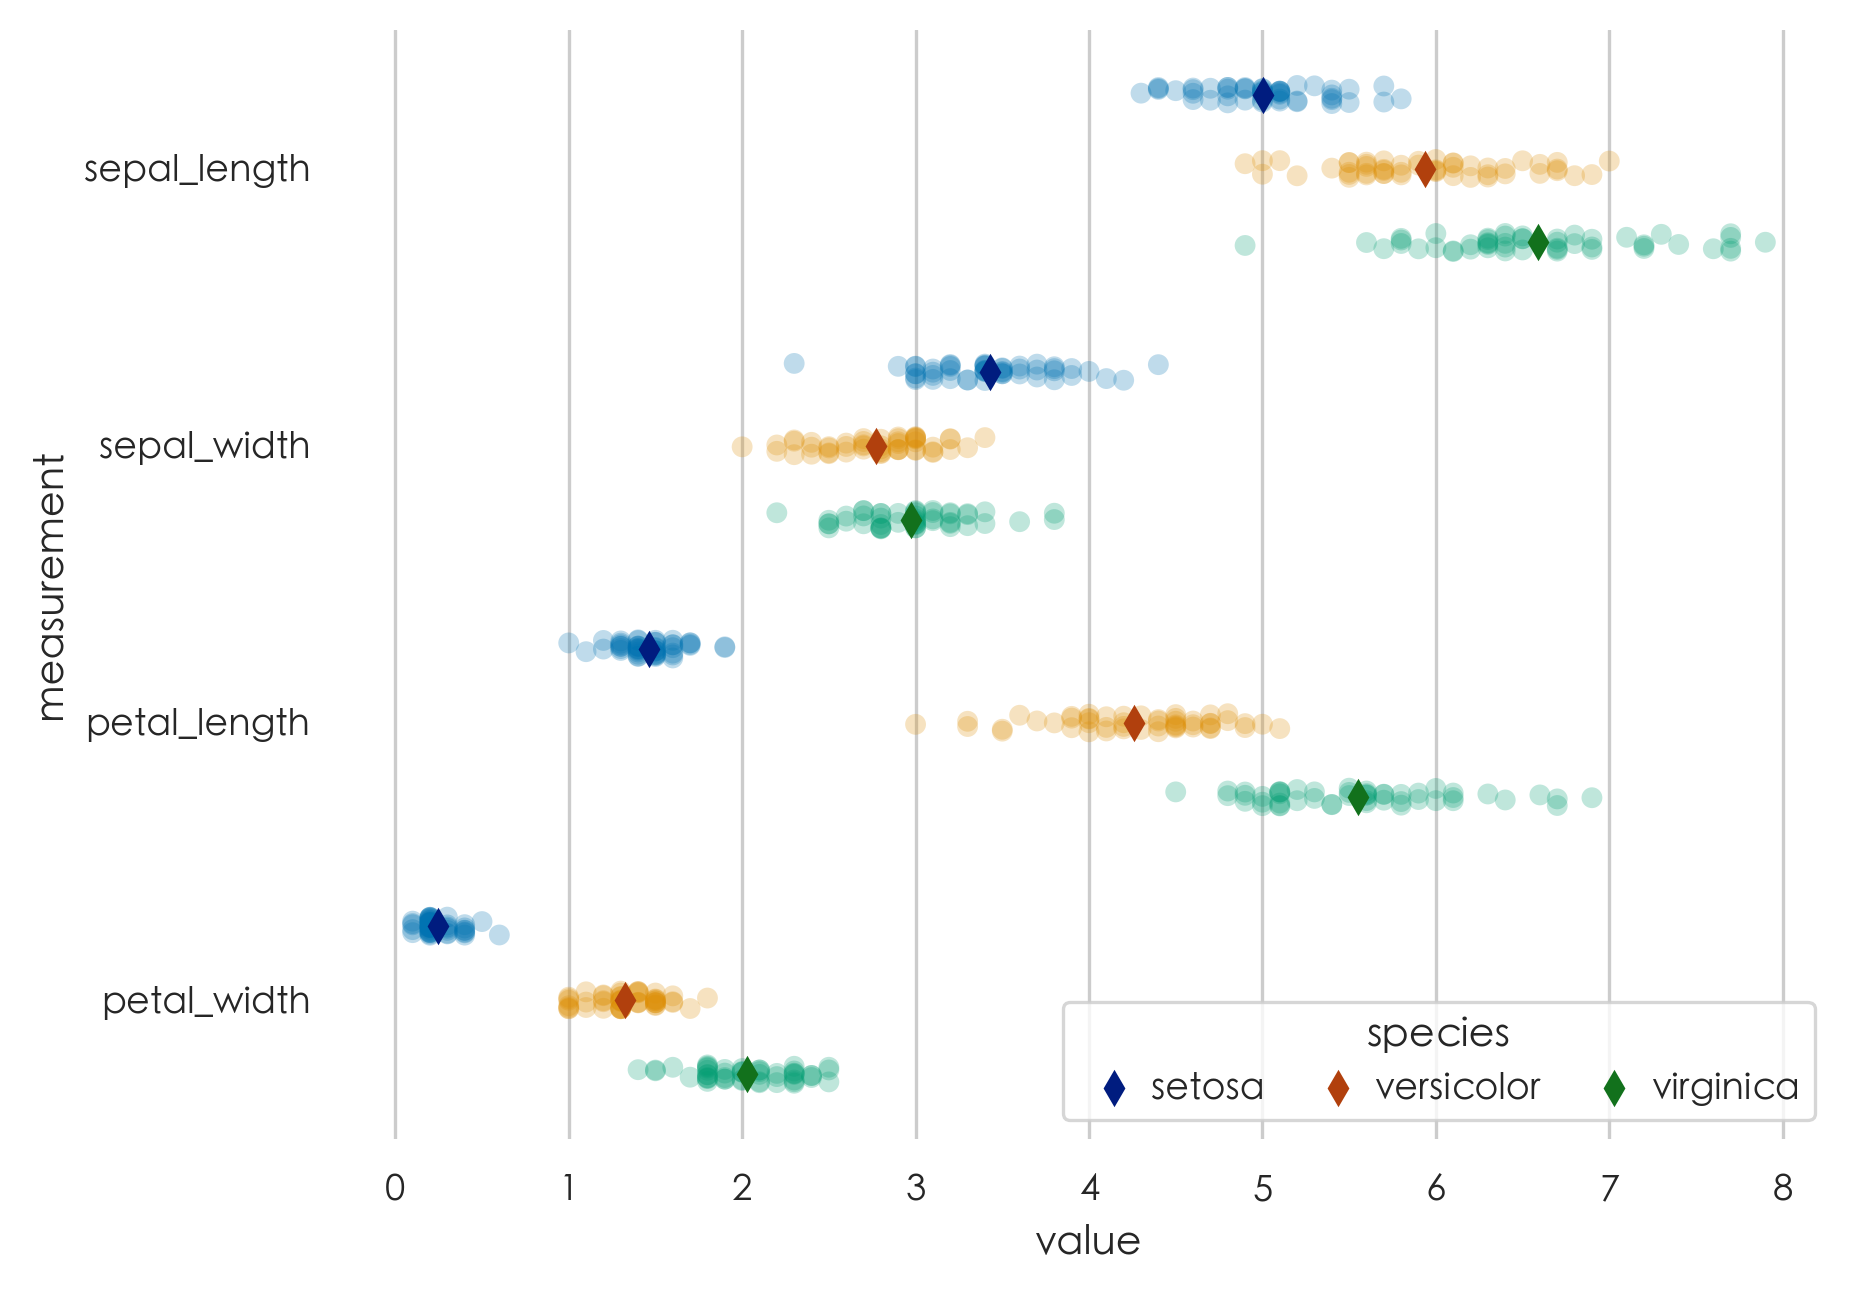

In [ ]:
iris = sns.load_dataset("iris")

# "Melt" the dataset to "long-form" or "tidy" representation
# 转化为长数据
# id_vars="species" 指定哪些列是标识变量（id variables），这些列不会被转换
# var_name="measurement" 指定转换后新列的名称，这里是测量
# 它们的数值会被放在一个名为 "value" 的新列中
iris = iris.melt(id_vars="species", var_name="measurement")

# Initialize the figure
f, ax = plt.subplots()
sns.despine(bottom=True, left=True)

# Show each observation with a scatterplot
sns.stripplot(
    data=iris, x="value", y="measurement", hue="species",
    dodge=True,     # dodge=True 会将不同物种（species）的点沿着Y轴“闪避”或“挪开”，让它们各自形成一簇，而不是混在一起
    alpha=.25, 
    zorder=1,   # 设置绘图的层次。zorder 值越小，图层越靠后。把它设为1，是为了确保它被画在背景
    legend=False,
)

# Show the conditional means, aligning each pointplot in the
# center of the strips by adjusting the width allotted to each
# category (.8 by default) by the number of hue levels
# 叠加均值点
sns.pointplot(
    data=iris, x="value", y="measurement", hue="species",
    dodge=.8 - .8 / 3,      # 确保每个菱形（均值点）都完美地落在其对应的那一簇散点（原始数据）的正中央
    palette="dark", 
    markers="d",    # 菱形 diamond
    markersize=4, 
    errorbar=None,
    linestyle="none",   # linestyle="none", errorbar=None: pointplot 默认会画连接线和误差棒。这里我们将它们全部去掉，因为我们只想要那个代表均值的点
)

# Improve the legend
# 移动图例
sns.move_legend(
    ax, 
    loc="lower right",  # 图例放置右下角
    ncol=3,         # 图例排成三列
    frameon=True,   # 为图例添加一个边框
    # 微调图例内部的间距，使其更美观
    columnspacing=1, 
    handletextpad=0,
)

# 联合分布图

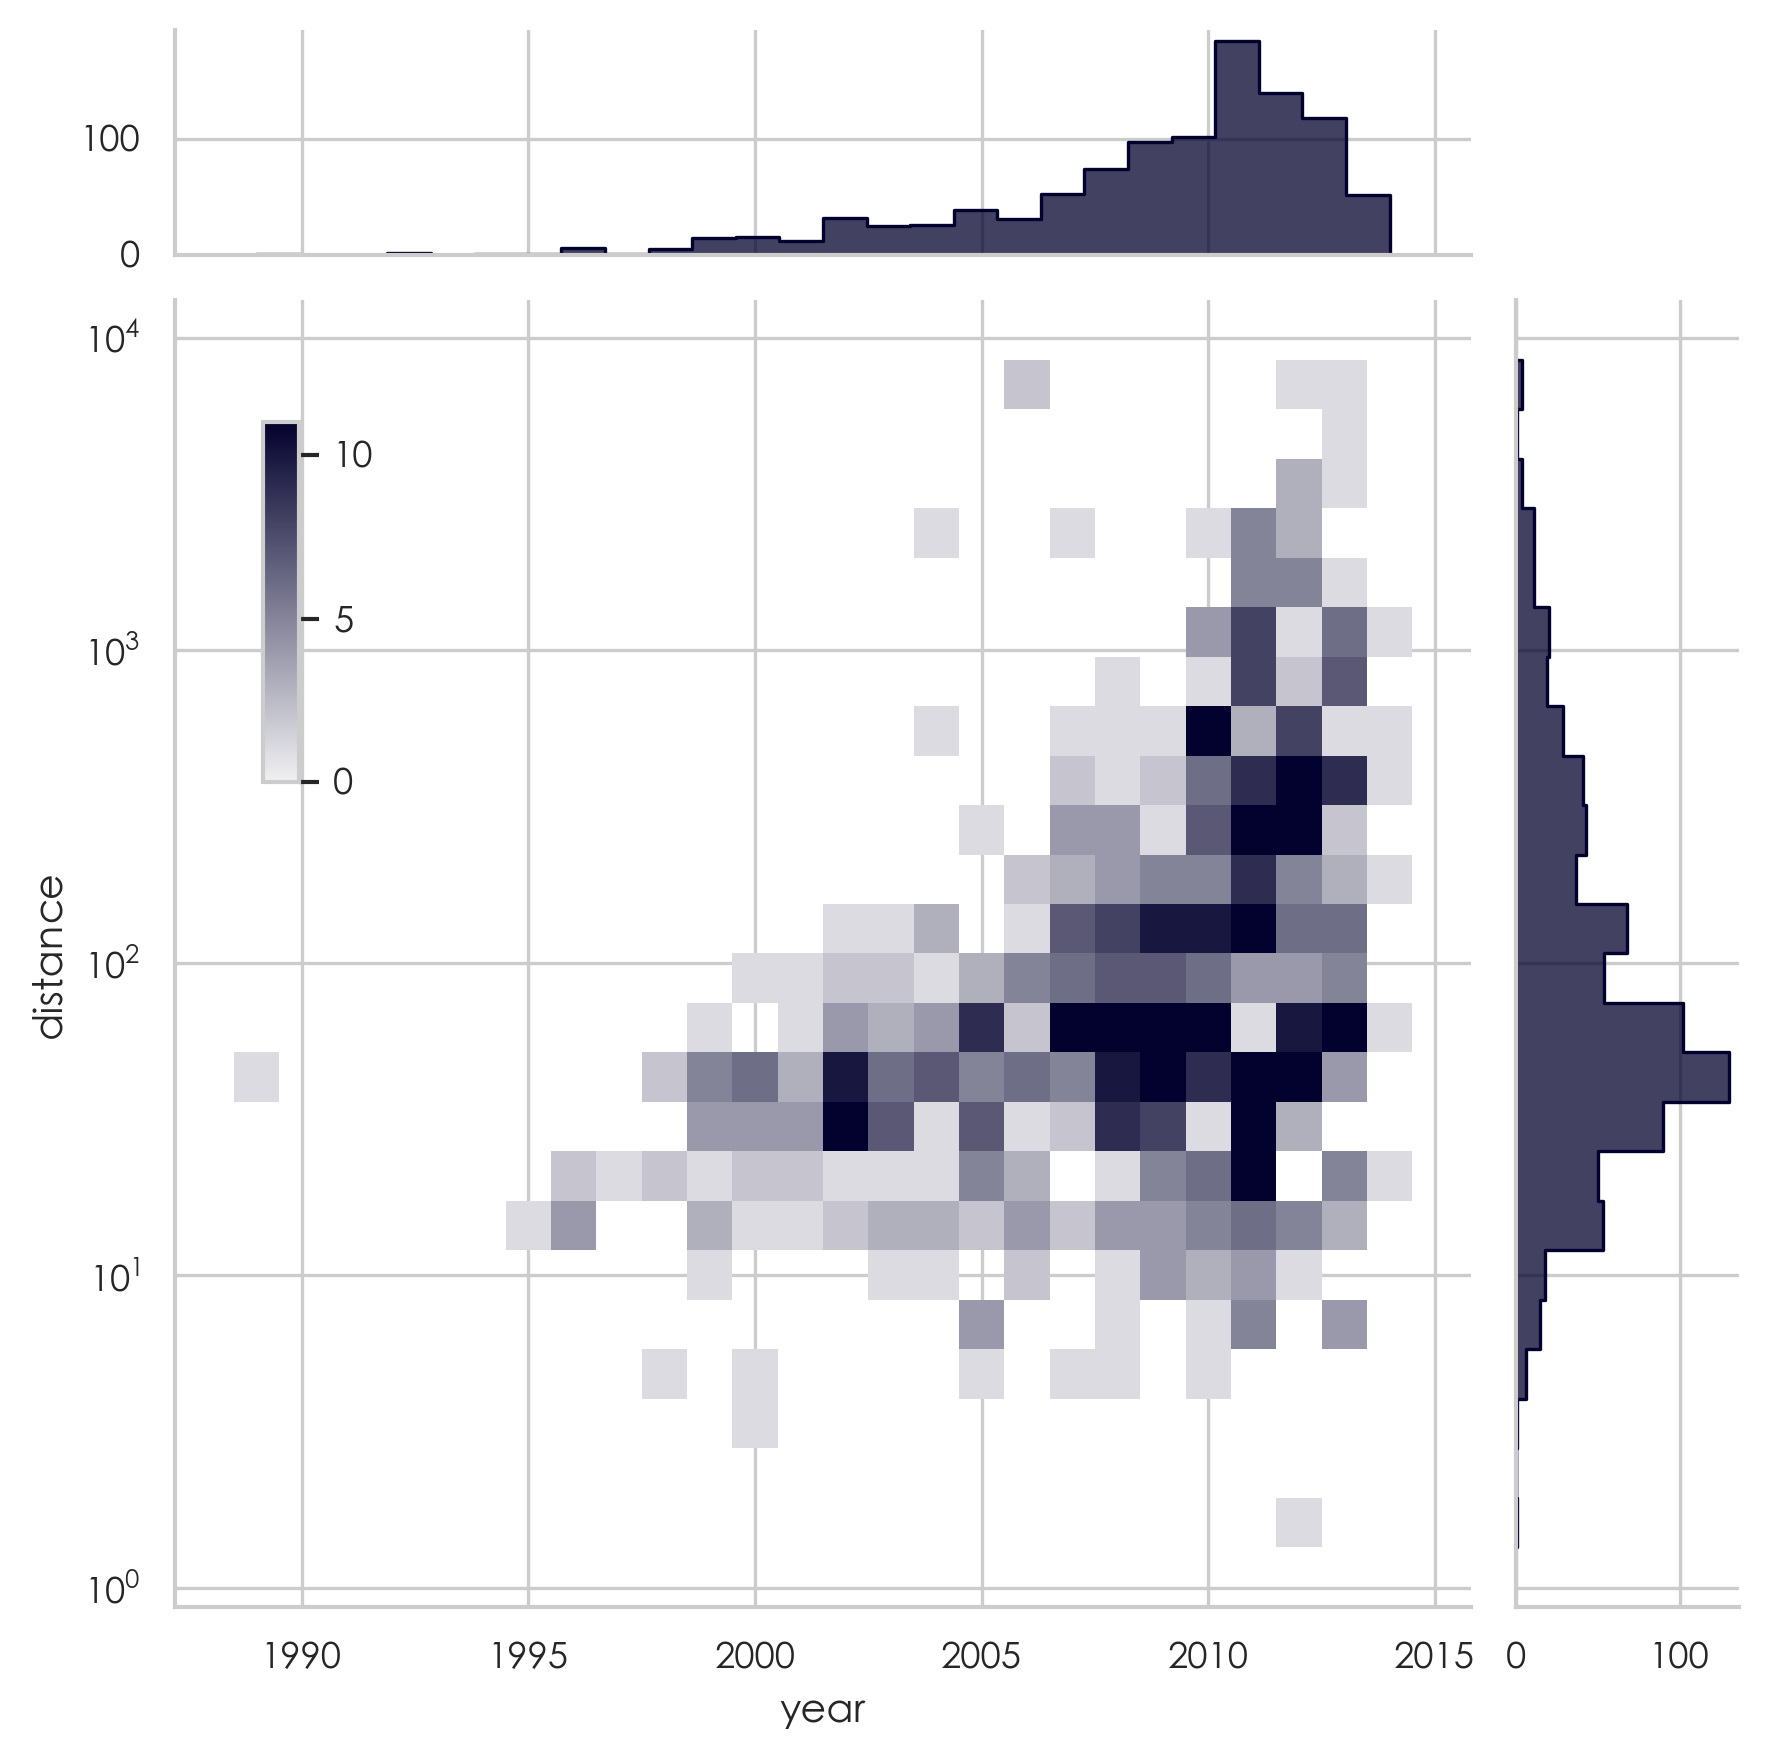

In [ ]:
# Load the planets dataset and initialize the figure
planets = sns.load_dataset("planets")
# 初始化一个空的联合分布图网格
g = sns.JointGrid(data=planets, x="year", y="distance", marginal_ticks=True)

# Set a log scaling on the y axis
g.ax_joint.set(yscale="log")

# Create an inset legend for the histogram colorbar
# 在整个图窗（figure）的指定位置手动添加一个新的、小号的坐标轴 cax
cax = g.figure.add_axes([.15, .55, .02, .2])    # 新坐标轴的 [左侧位置, 底部位置, 宽度, 高度]

# Add the joint and marginal histogram plots
# 主体区域绘图
g.plot_joint(
    sns.histplot, 
    discrete=(True, False),     # x 轴离散， y 轴连续
    cmap="light:#03012d", 
    pmax=.8,    # 调整颜色映射的范围，使得数据点计数排在后80%的箱子能更好地在颜色上体现出差异，避免极端值影响整体的颜色显示。
    cbar=True,  # 创建一个颜色条图例
    cbar_ax=cax
)
# 边际区域绘图
g.plot_marginals(sns.histplot, 
                 element="step",    # 让直方图不显示为填充的条形，而是只显示阶梯状的轮廓线
                 color="#03012d")

''' 
sns.JointGrid: 它是一个对象，是一个“绘图框架”。当你初始化它时，它只为你创建一个空的、包含三个区域的绘图网格 
    g.ax_joint: 中间的主体区域。
    g.ax_marg_x: 顶部的X轴边缘区域。
    g.ax_marg_y: 右侧的Y轴边缘区域。
'''

# 核密度联合分布图

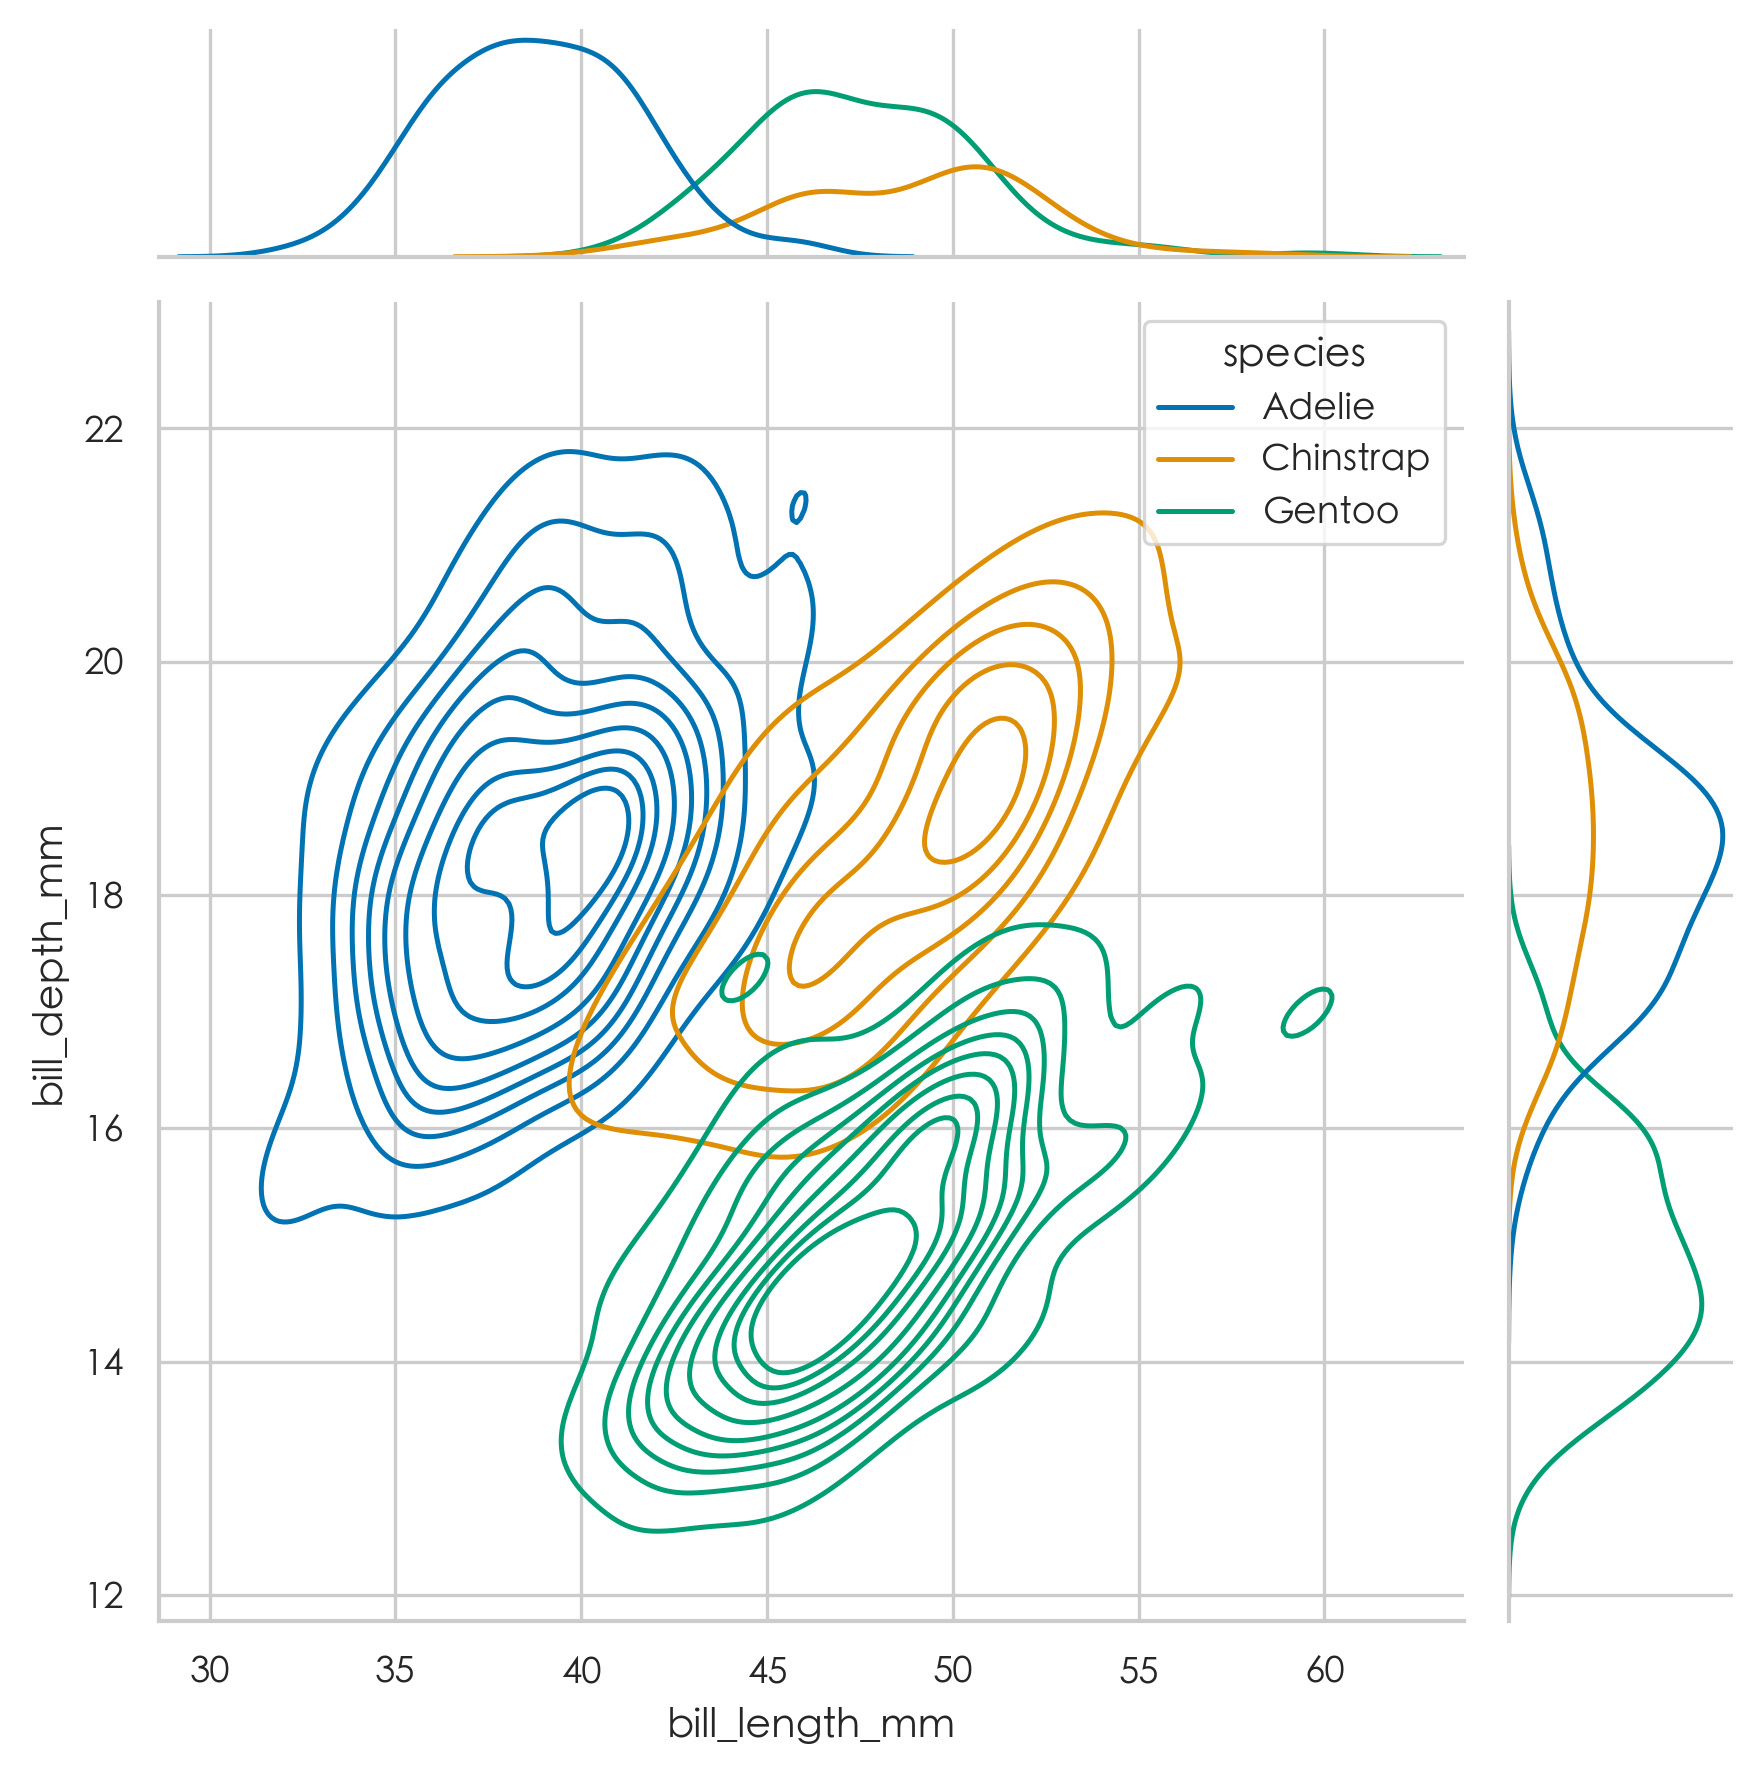

In [4]:
# Load the penguins dataset
penguins = sns.load_dataset("penguins")

# Show the joint distribution using kernel density estimation
g = sns.jointplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="species",
    kind="kde",
)

# 山脊图

/Users/solidify/miniconda3/envs/torch_env/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


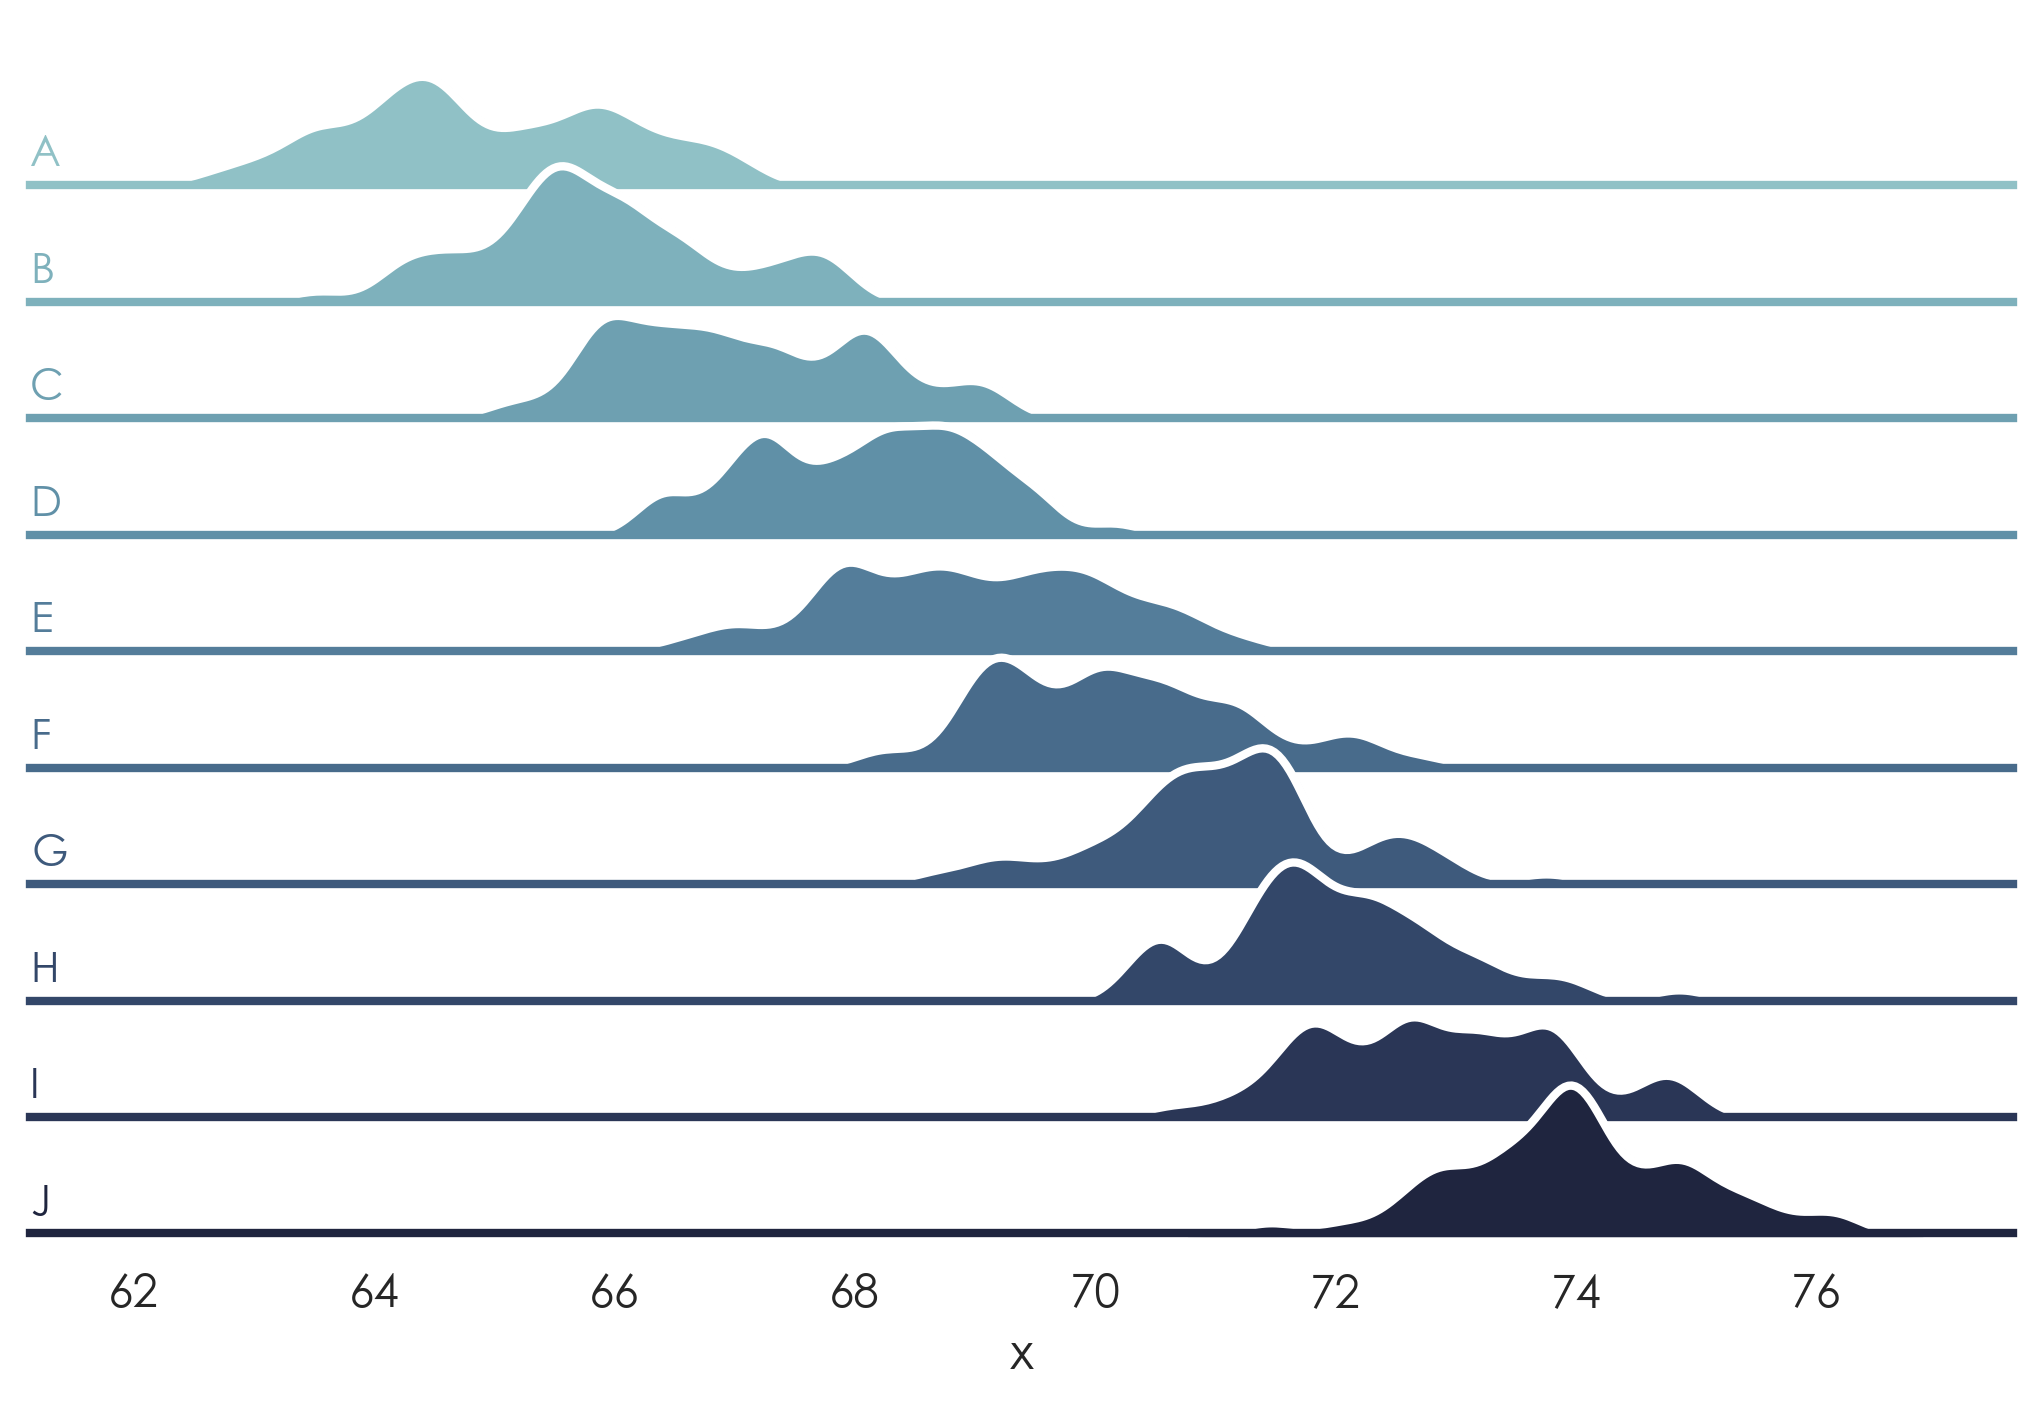

In [ ]:
# Create the data
rs = np.random.RandomState(1979)
x = rs.randn(500)
g = np.tile(list("ABCDEFGHIJ"), 50)
df = pd.DataFrame(dict(x=x, g=g))
m = df.g.map(ord)
df["x"] += m

# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
# 初始化空的网络
g = sns.FacetGrid(df, 
                  row="g",  # 据数据中 g 这一列的每个类别分别创建一行子图
                  hue="g", 
                  aspect=15, # 将每个子图设置成极宽（aspect=15）但极矮（height=.5）的形状
                  height=.5, 
                  palette=pal)

''' 局部设置：不在开头使用 sns.set_theme()'''
# 全局重置
sns.reset_defaults()


# Draw the densities in a few steps
# 使用 .map() 进行多层绘图

# 第一层：填充的山脊
g.map(sns.kdeplot, 
      "x",
      bw_adjust=.5, 
      clip_on=False,    # 允许图形绘制到坐标轴区域之外
      fill=True, 
      alpha=1, 
      linewidth=1.5)

# 第二层：白色的轮廓线
g.map(sns.kdeplot, 
      "x", 
      clip_on=False, 
      color="w", 
      lw=2, 
      bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
# 第三层：黑色的基准线
# g.refline(): 这是 FacetGrid 的一个特殊方法，可以在每个子图的指定y值位置画一条参考线
g.refline(y=0, 
          linewidth=2, 
          linestyle="-", 
          color=None, 
          clip_on=False)

# 此时布局已定，可以安全地添加样式了

# 【局部字体设置】在需要用到字体之前，进行设置
# 这只会影响在此之后绘制的文本元素
plt.rcParams['font.sans-serif'] = ['STHeiti']  # Mac
# plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows
plt.rcParams['axes.unicode_minus'] = False

# Define and use a simple function to label the plot in axes coordinates
# 自定义标签与最终布局
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "x")

# Set the subplots to overlap
# 实现重叠效果与最终清理
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# 保存为高分辨率的PNG文件
plt.savefig("ridgeline_high_res.png", dpi=300, bbox_inches='tight')

# 保存为矢量图（无限清晰度，推荐论文使用）
plt.savefig("ridgeline_vector.pdf", bbox_inches='tight')
plt.show()

# 信函值图

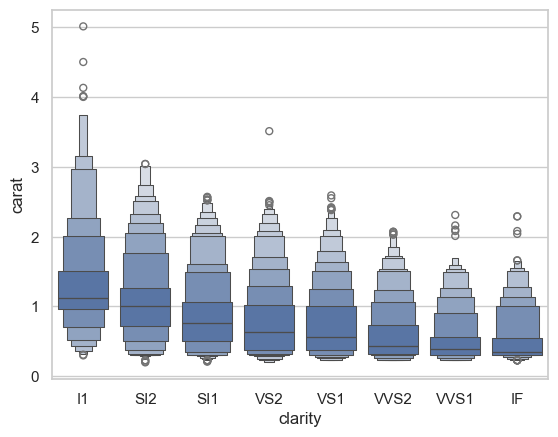

In [22]:
sns.set_theme(style="whitegrid")

diamonds = sns.load_dataset("diamonds")
clarity_ranking = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

sns.boxenplot(
    diamonds, 
    x="clarity", 
    y="carat",
    color="b", 
    order=clarity_ranking, 
    width_method="linear",  # 控制着从中心向外，每个嵌套箱体的宽度是如何递减的
    # "exponential" (指数递减，默认值): 每个内层箱体的宽度是外层箱体宽度的一个固定比例
    # width_method='exponential'
)
plt.show()

# 二维密度图

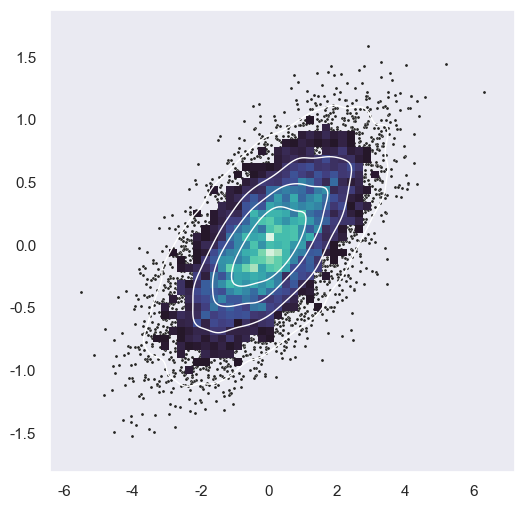

In [ ]:
sns.set_theme(style="dark")

# Simulate data from a bivariate Gaussian
n = 10000
mean = [0, 0]
cov = [(2, .4), (.4, .2)]
rng = np.random.RandomState(0)
x, y = rng.multivariate_normal(mean, cov, n).T

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(6, 6))
# 第一层（底层）：散点图“星空”
sns.scatterplot(x=x, y=y, s=5, color=".15")
# 第二层（中层）：二维直方图“星云”
sns.histplot(x=x, y=y, bins=50, 
             pthresh=.1,    # 只对那些数据点数量超过“最密集网格10%”的格子进行着色
             cmap="mako")
# 第三层（顶层）：核密度估计“等高线”
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)

plt.show()

# 填充堆叠密度图

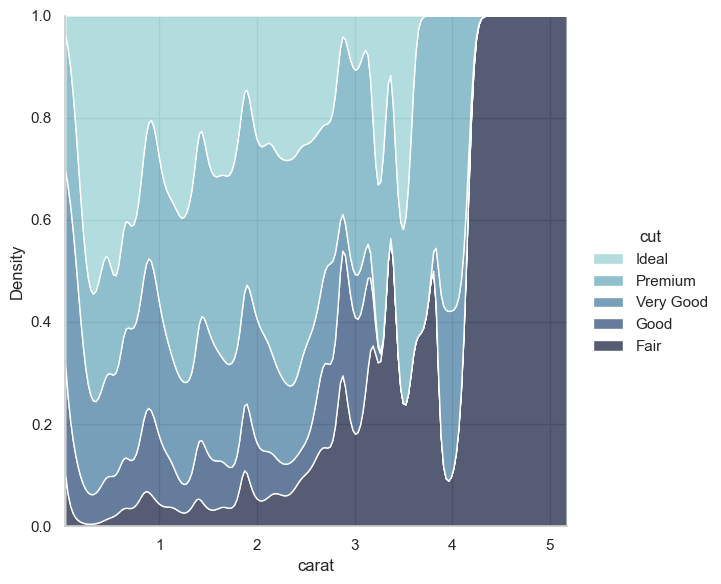

In [ ]:
sns.set_theme(style="whitegrid")

# Load the diamonds dataset
diamonds = sns.load_dataset("diamonds")

# Plot the distribution of clarity ratings, conditional on carat
sns.displot(
    data=diamonds,
    x="carat", hue="cut",
    kind="kde", height=6,
    multiple="fill", # 创建100%比例的堆叠图
    clip=(0, None), # 将密度曲线在X轴的0位置“裁剪”掉，防止曲线延伸到无意义的负数范围
    palette="ch:rot=-.25,hue=1,light=.75",
)
plt.show()

# 残差图

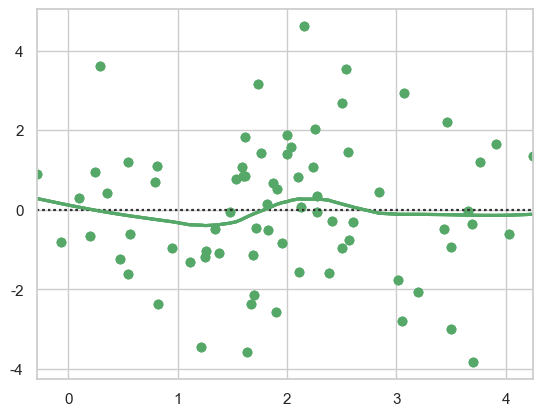

In [31]:
sns.set_theme(style="whitegrid")

# Make an example dataset with y ~ x
rs = np.random.RandomState(7)
x = rs.normal(2, 1, 75)
y = 2 + 1.5 * x + rs.normal(0, 2, 75)

# Plot the residuals after fitting a linear model
sns.residplot(x=x, y=y, lowess=True, color="g")
plt.show()

# 配对图

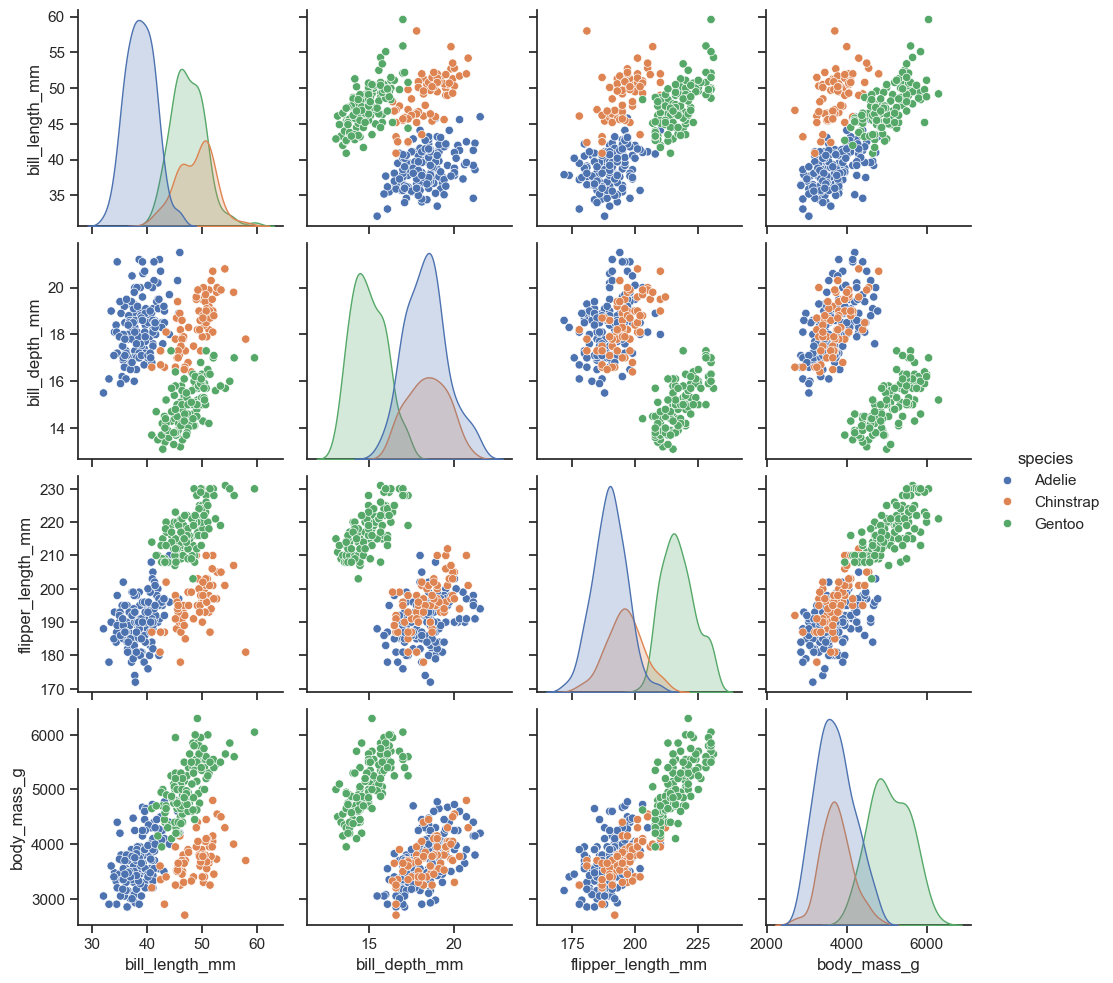

In [34]:
sns.set_theme(style="ticks")

df = sns.load_dataset("penguins")
# pairplot 会自动抓取你的数据（df）中所有的数值型列，然后创建一个N x N的子图网格，其中N是数值型列的数量。
# 这个网格由两种类型的图组成：单变量分布 与 双变量分布
sns.pairplot(df, hue="species")
plt.show()